Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using file: /content/drive/MyDrive/spotify/spotify-2023.csv

Columns found:
['track_name', 'artist_s__name', 'artist_count', 'released_year', 'released_month', 'released_day', 'in_spotify_playlists', 'in_spotify_charts', 'streams', 'in_apple_playlists', 'in_apple_charts', 'in_deezer_playlists', 'in_deezer_charts', 'in_shazam_charts', 'bpm', 'key', 'mode', 'danceability', 'valence', 'energy', 'acousticness', 'instrumentalness', 'liveness', 'speechiness']

Prepared dataset shape: (952, 16)
Top artists defined: 238 songs from top-tier artists

Descriptive statistics:
            streams  in_spotify_playlists  in_apple_playlists  \
count  9.520000e+02            952.000000          952.000000   
mean   5.141374e+08           5202.565126           67.866597   
std    5.668569e+08           7901.400683           86.470591   
min    2.762000e+03             31.00000

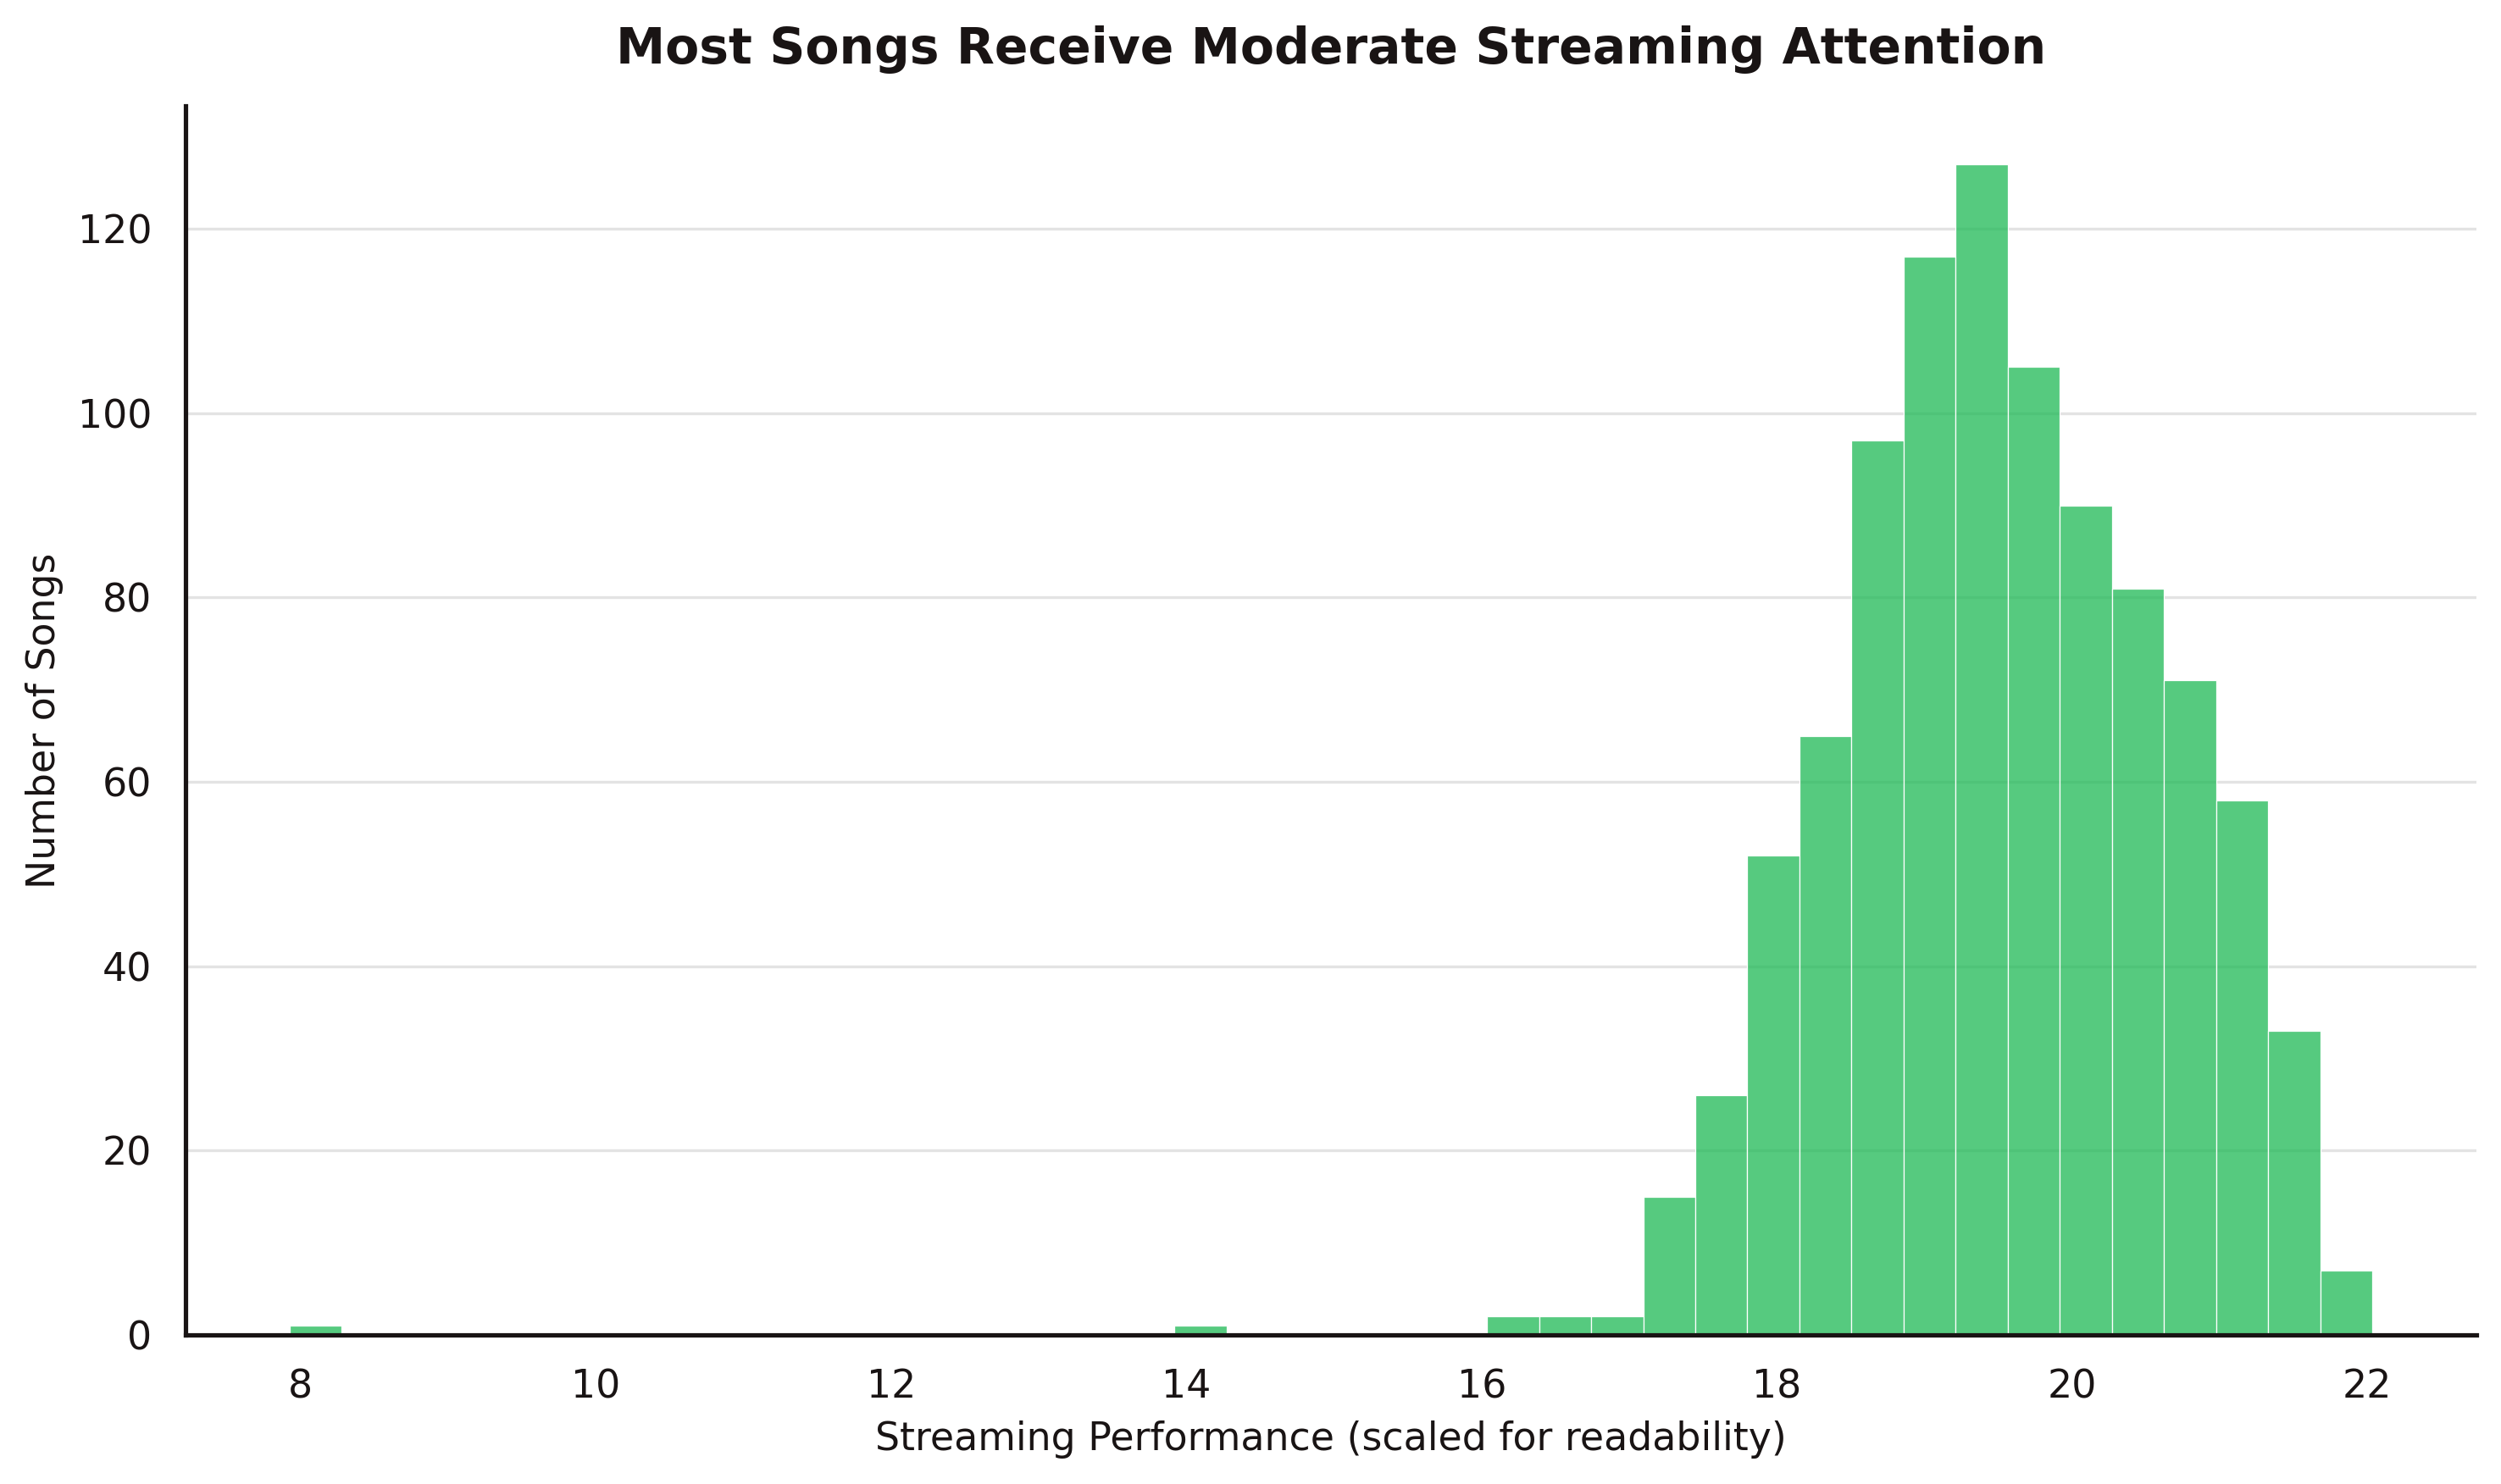

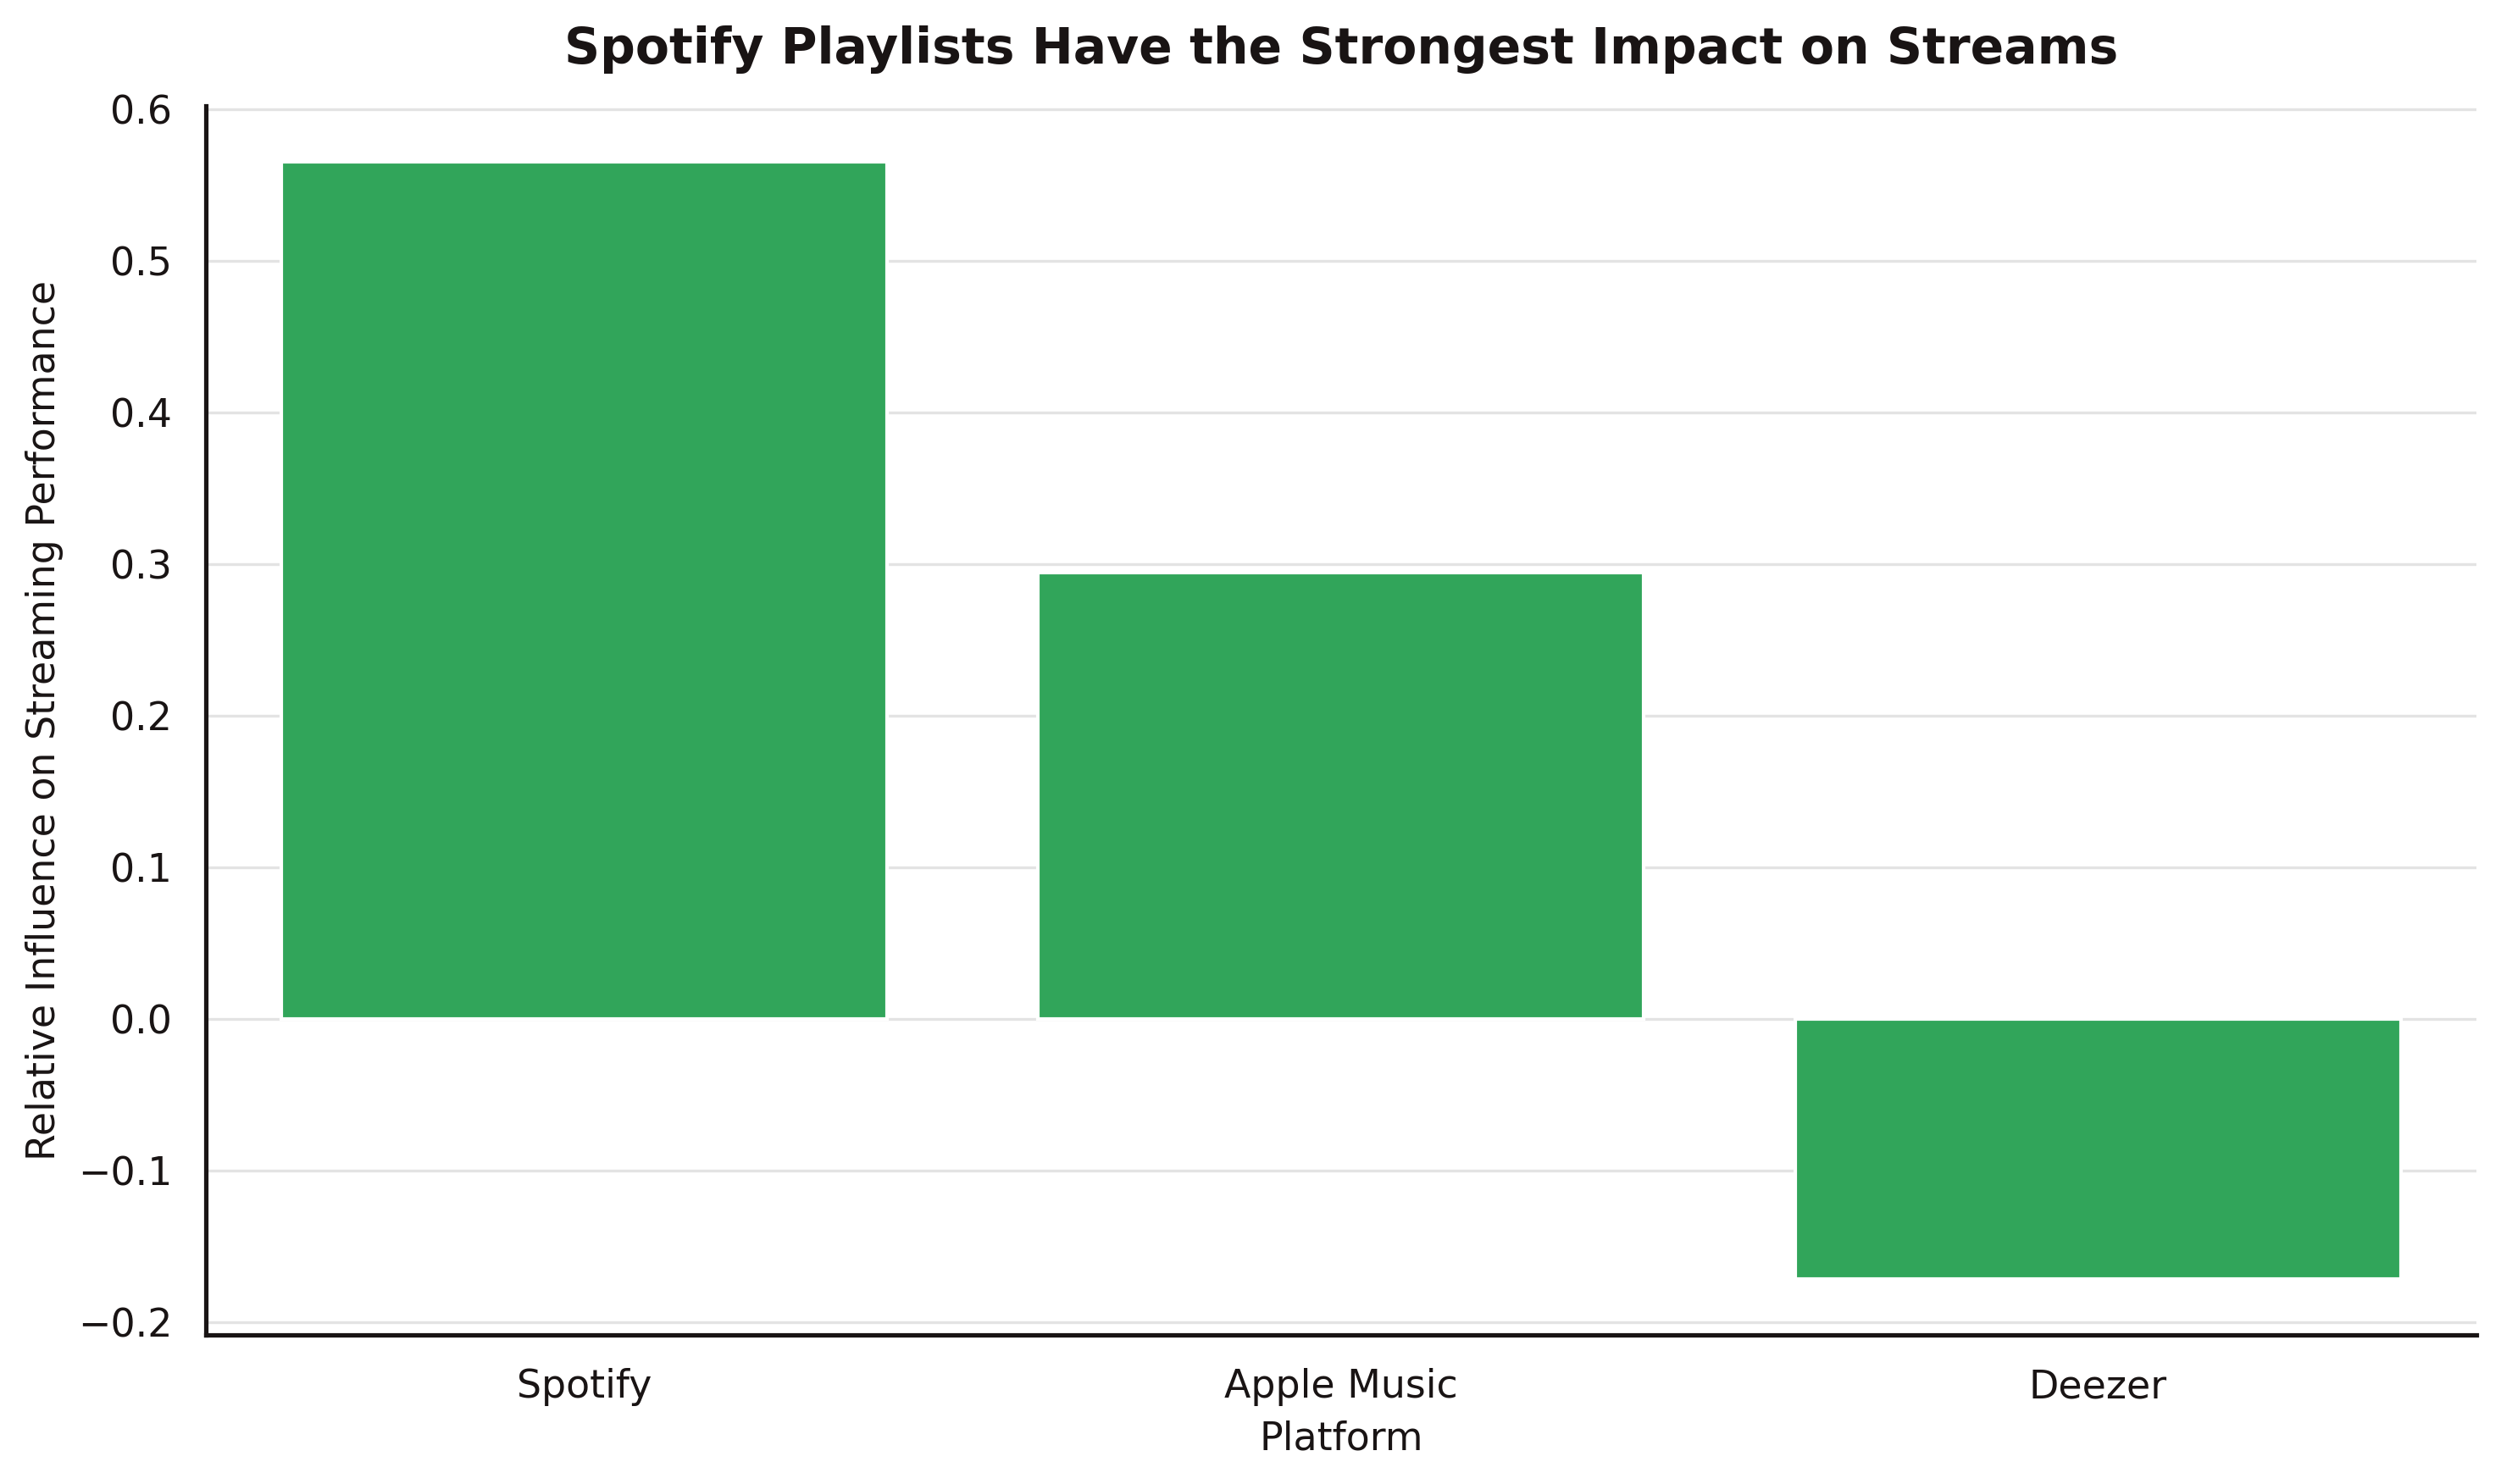

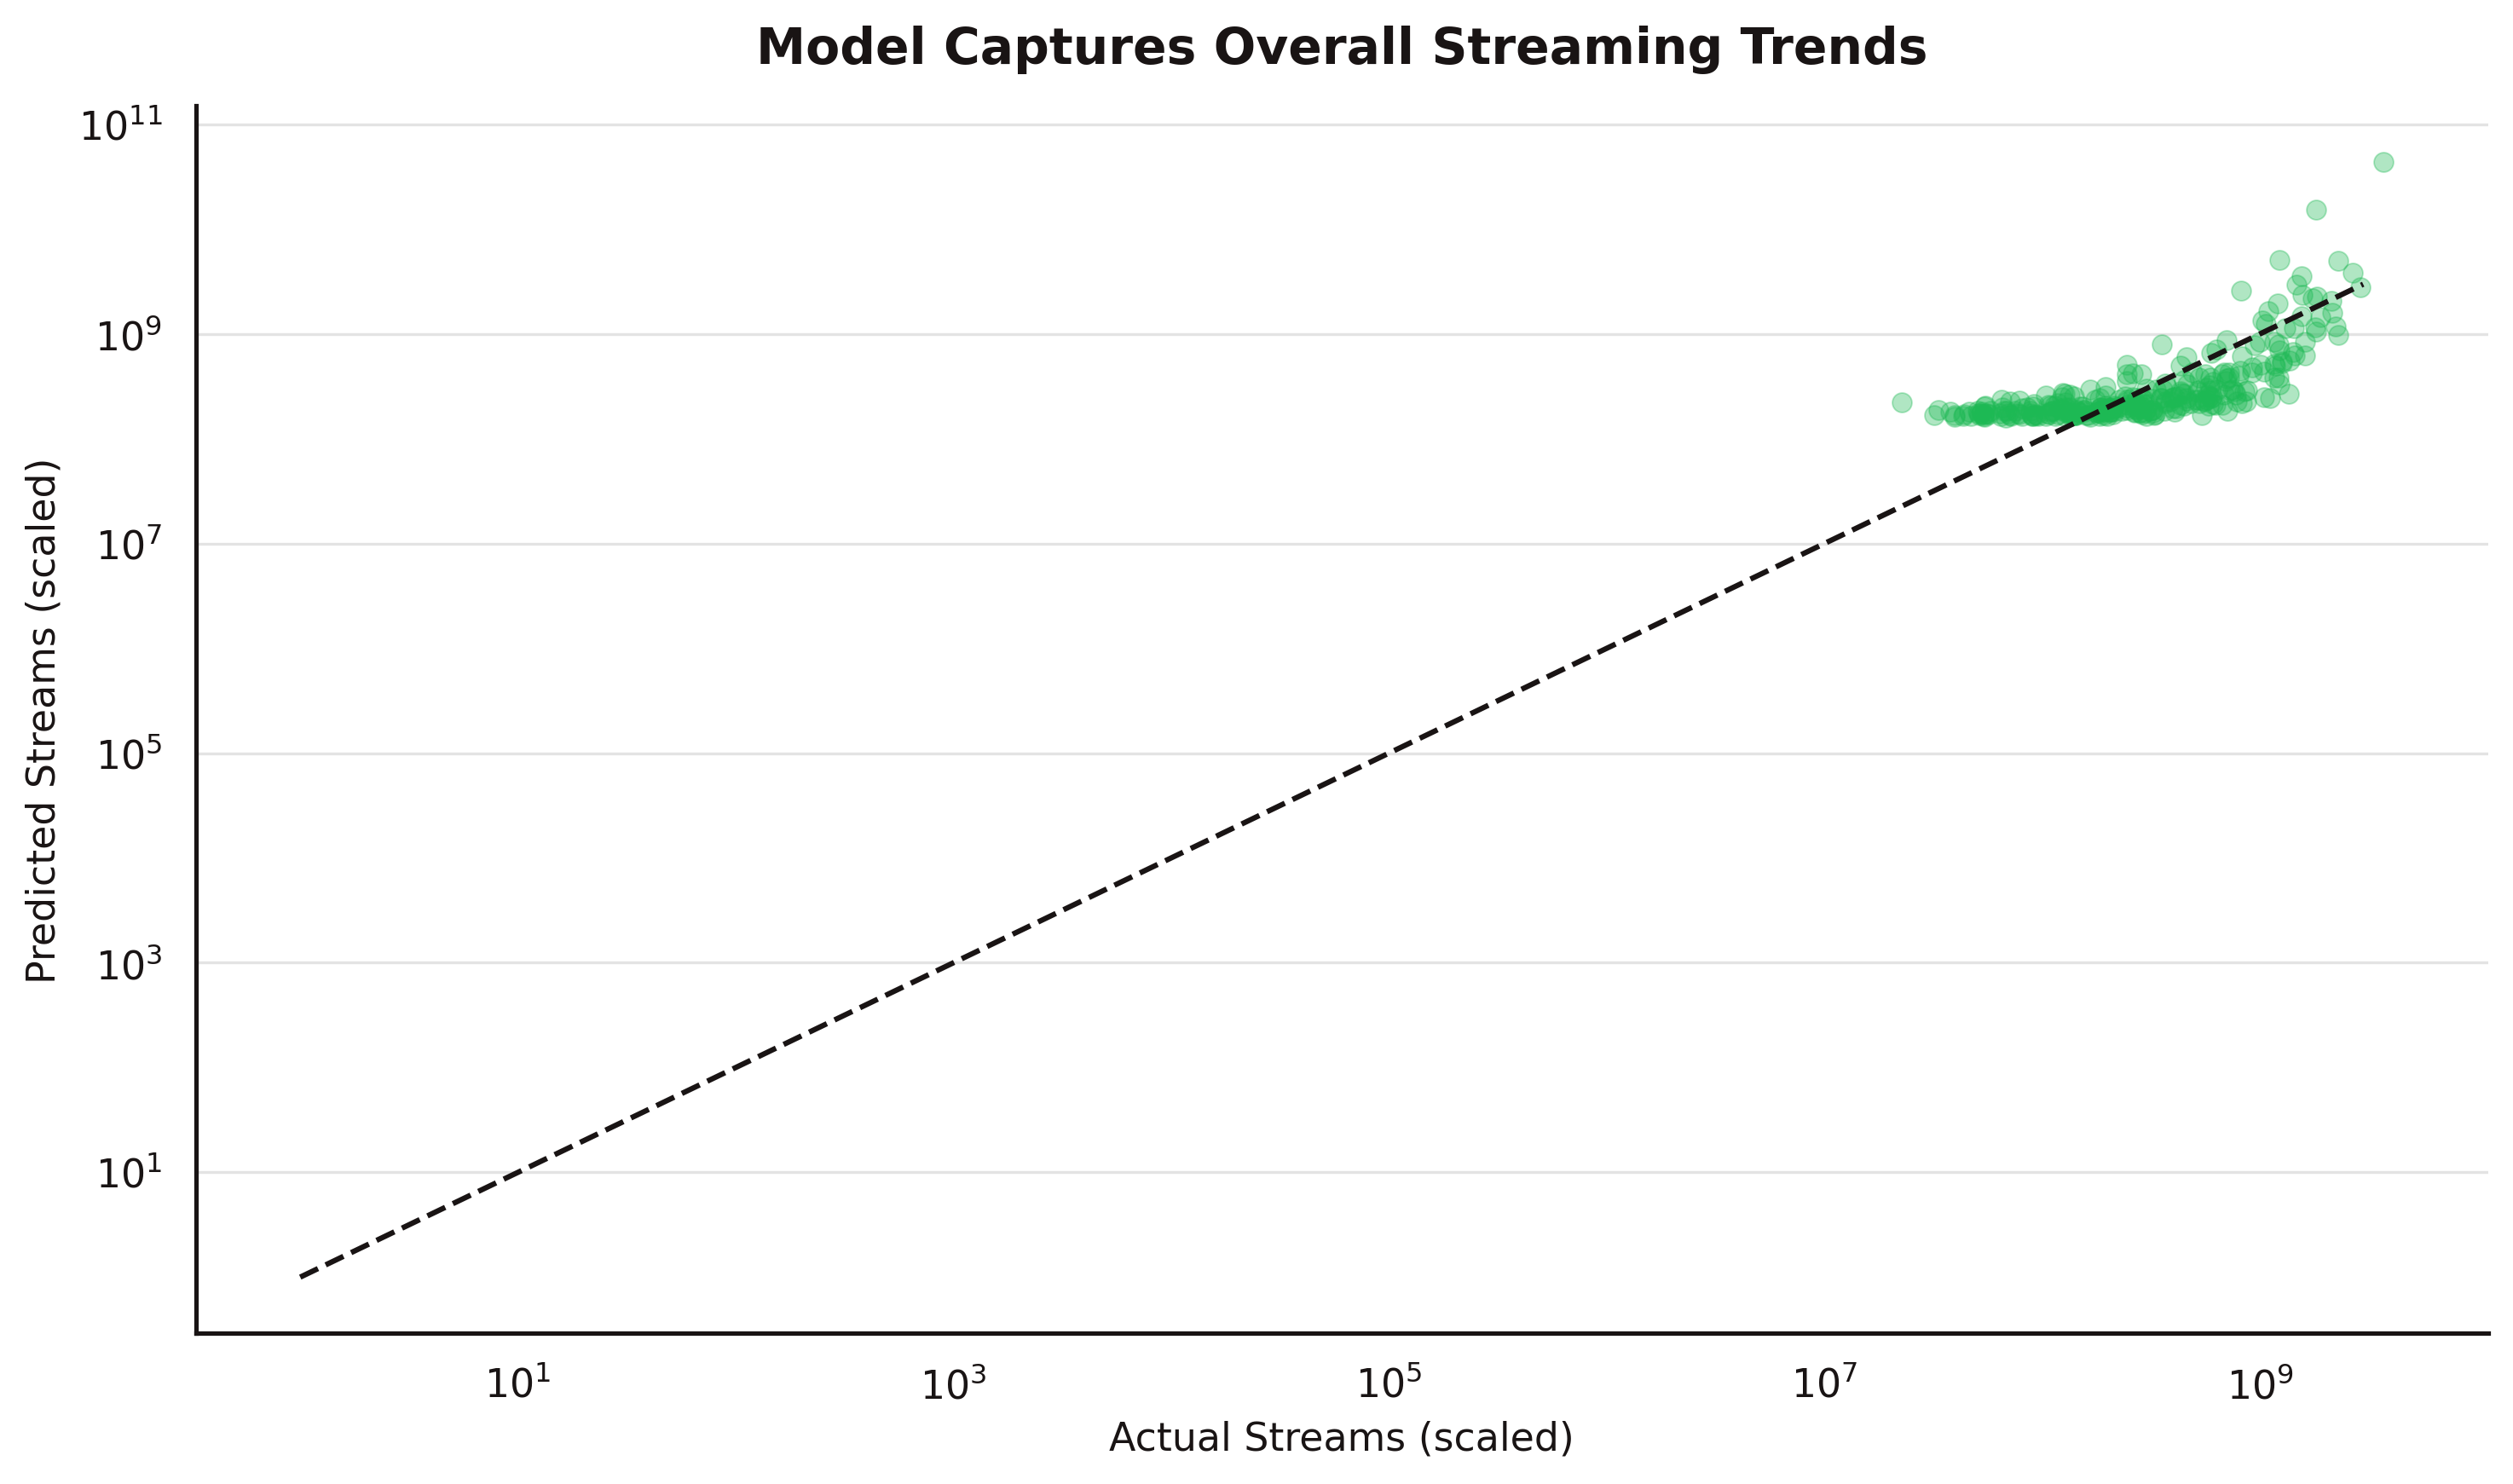

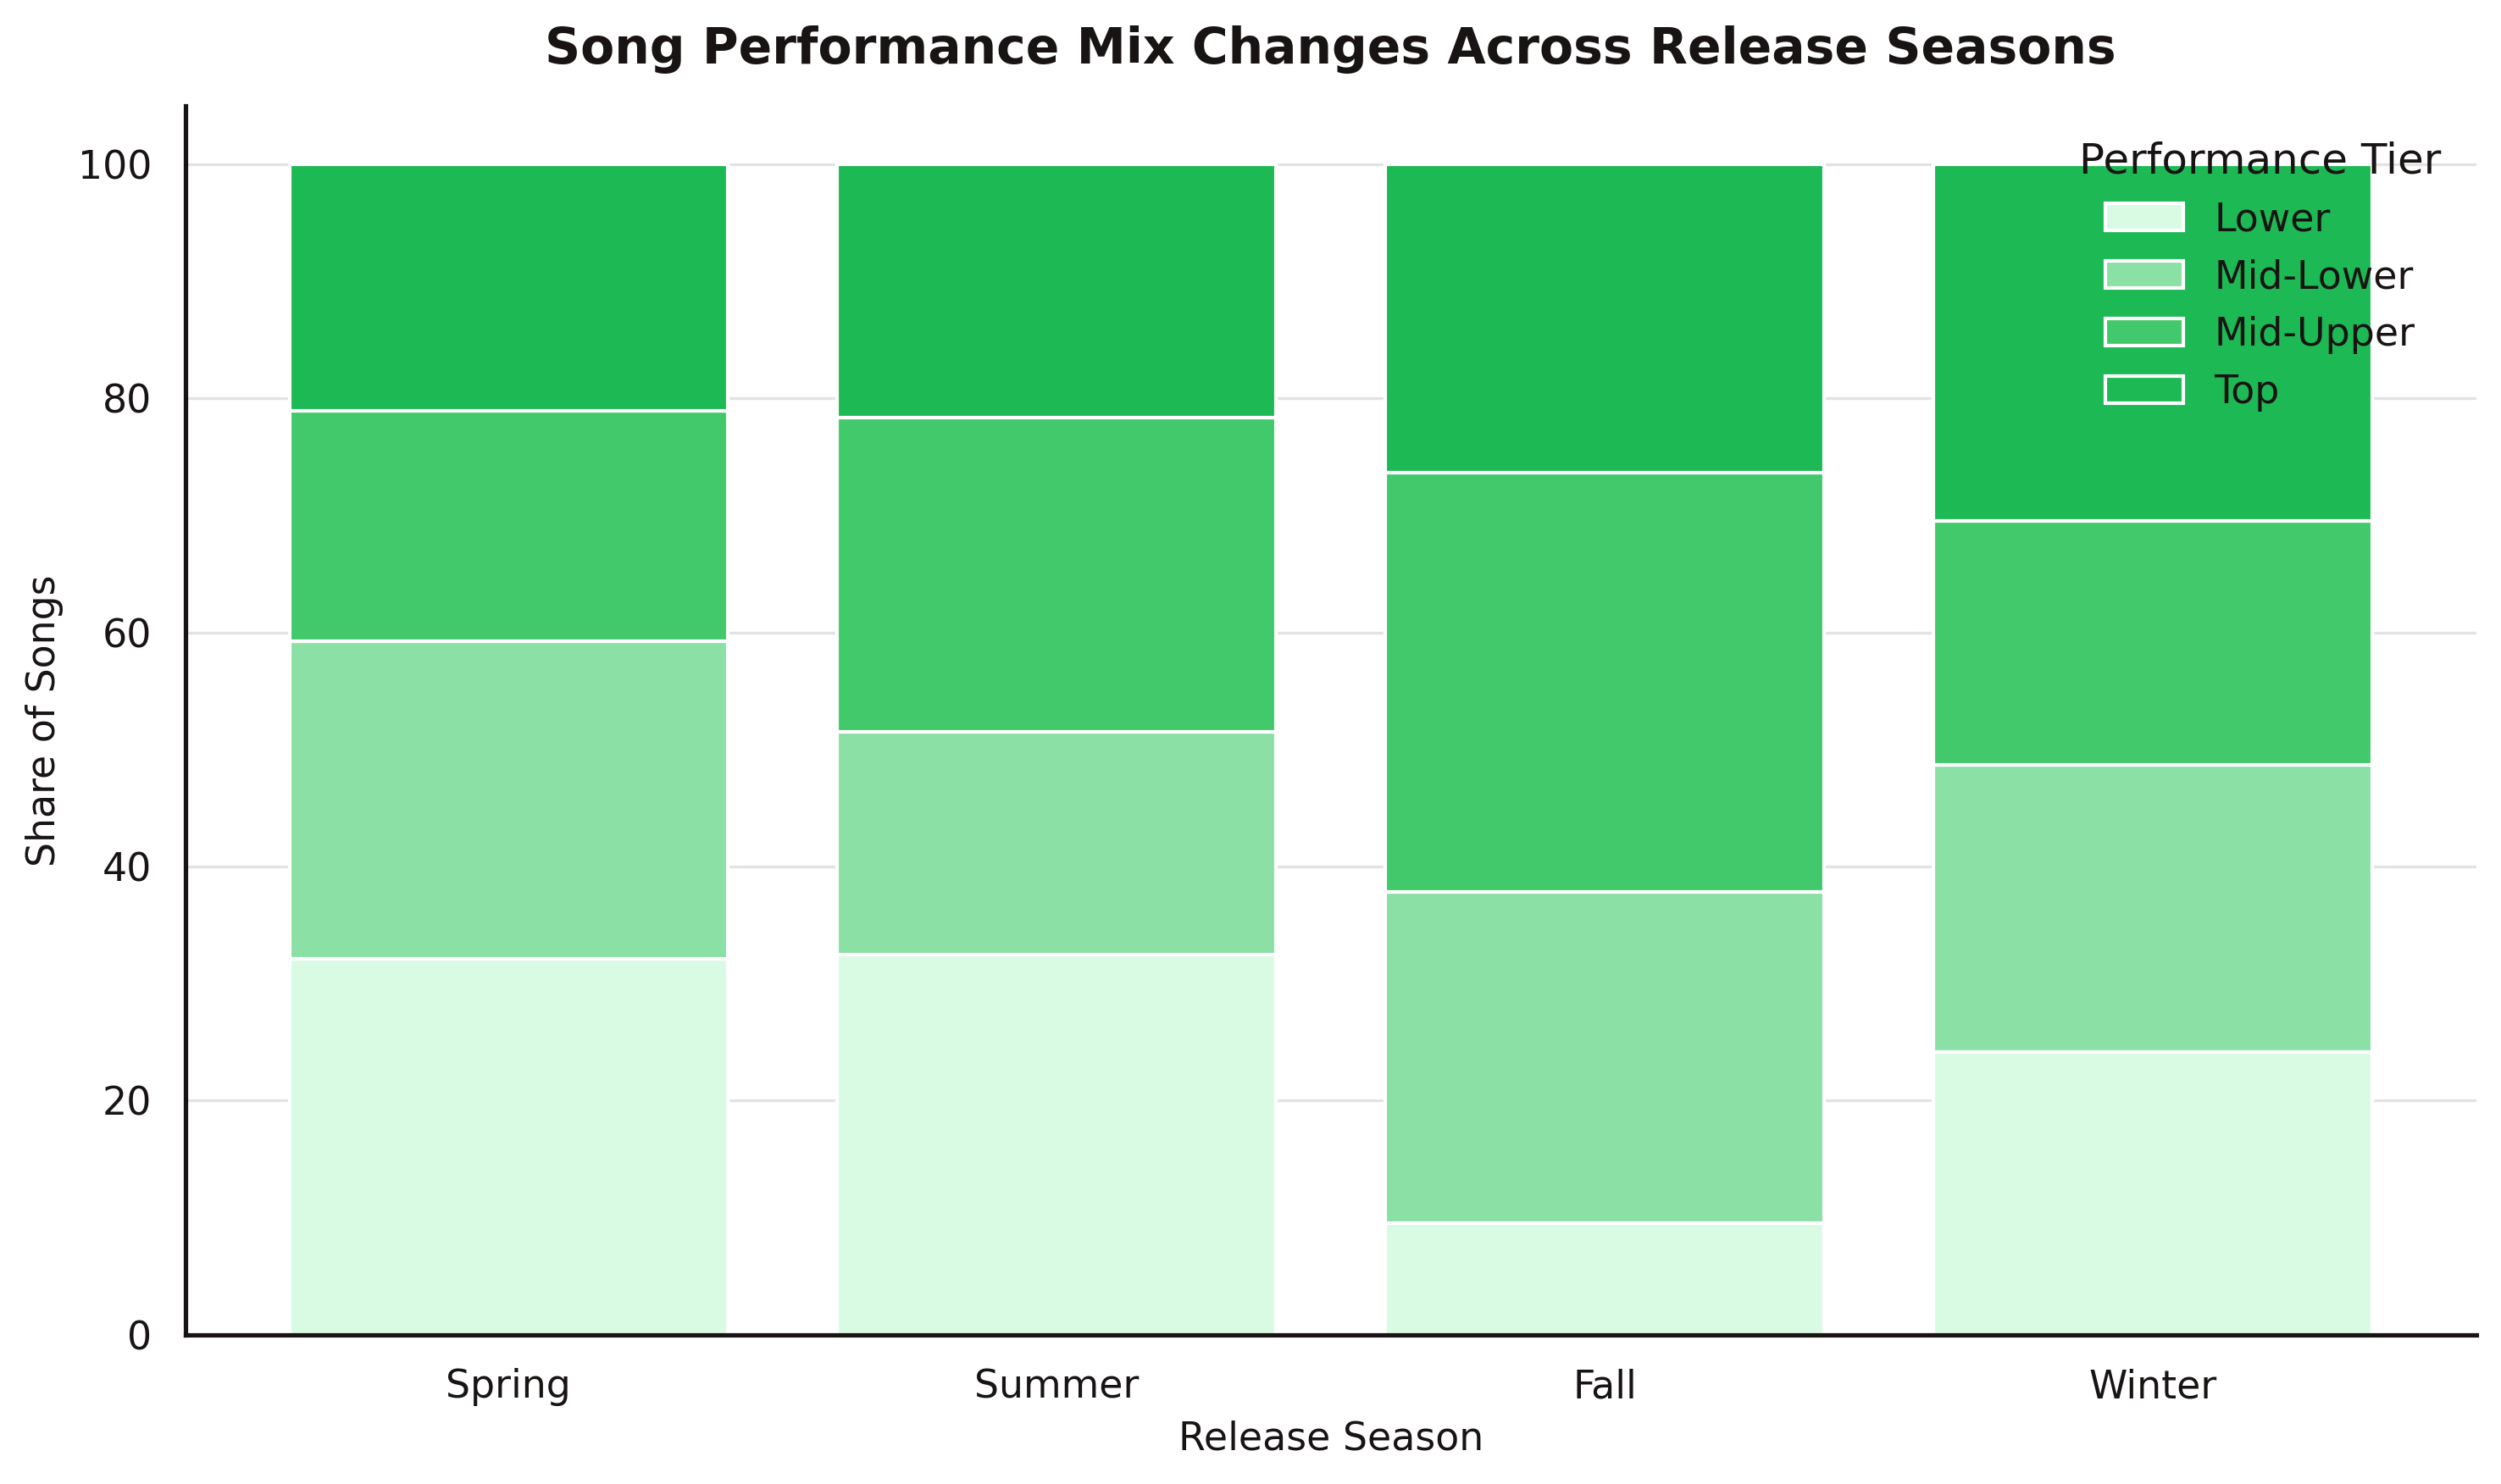

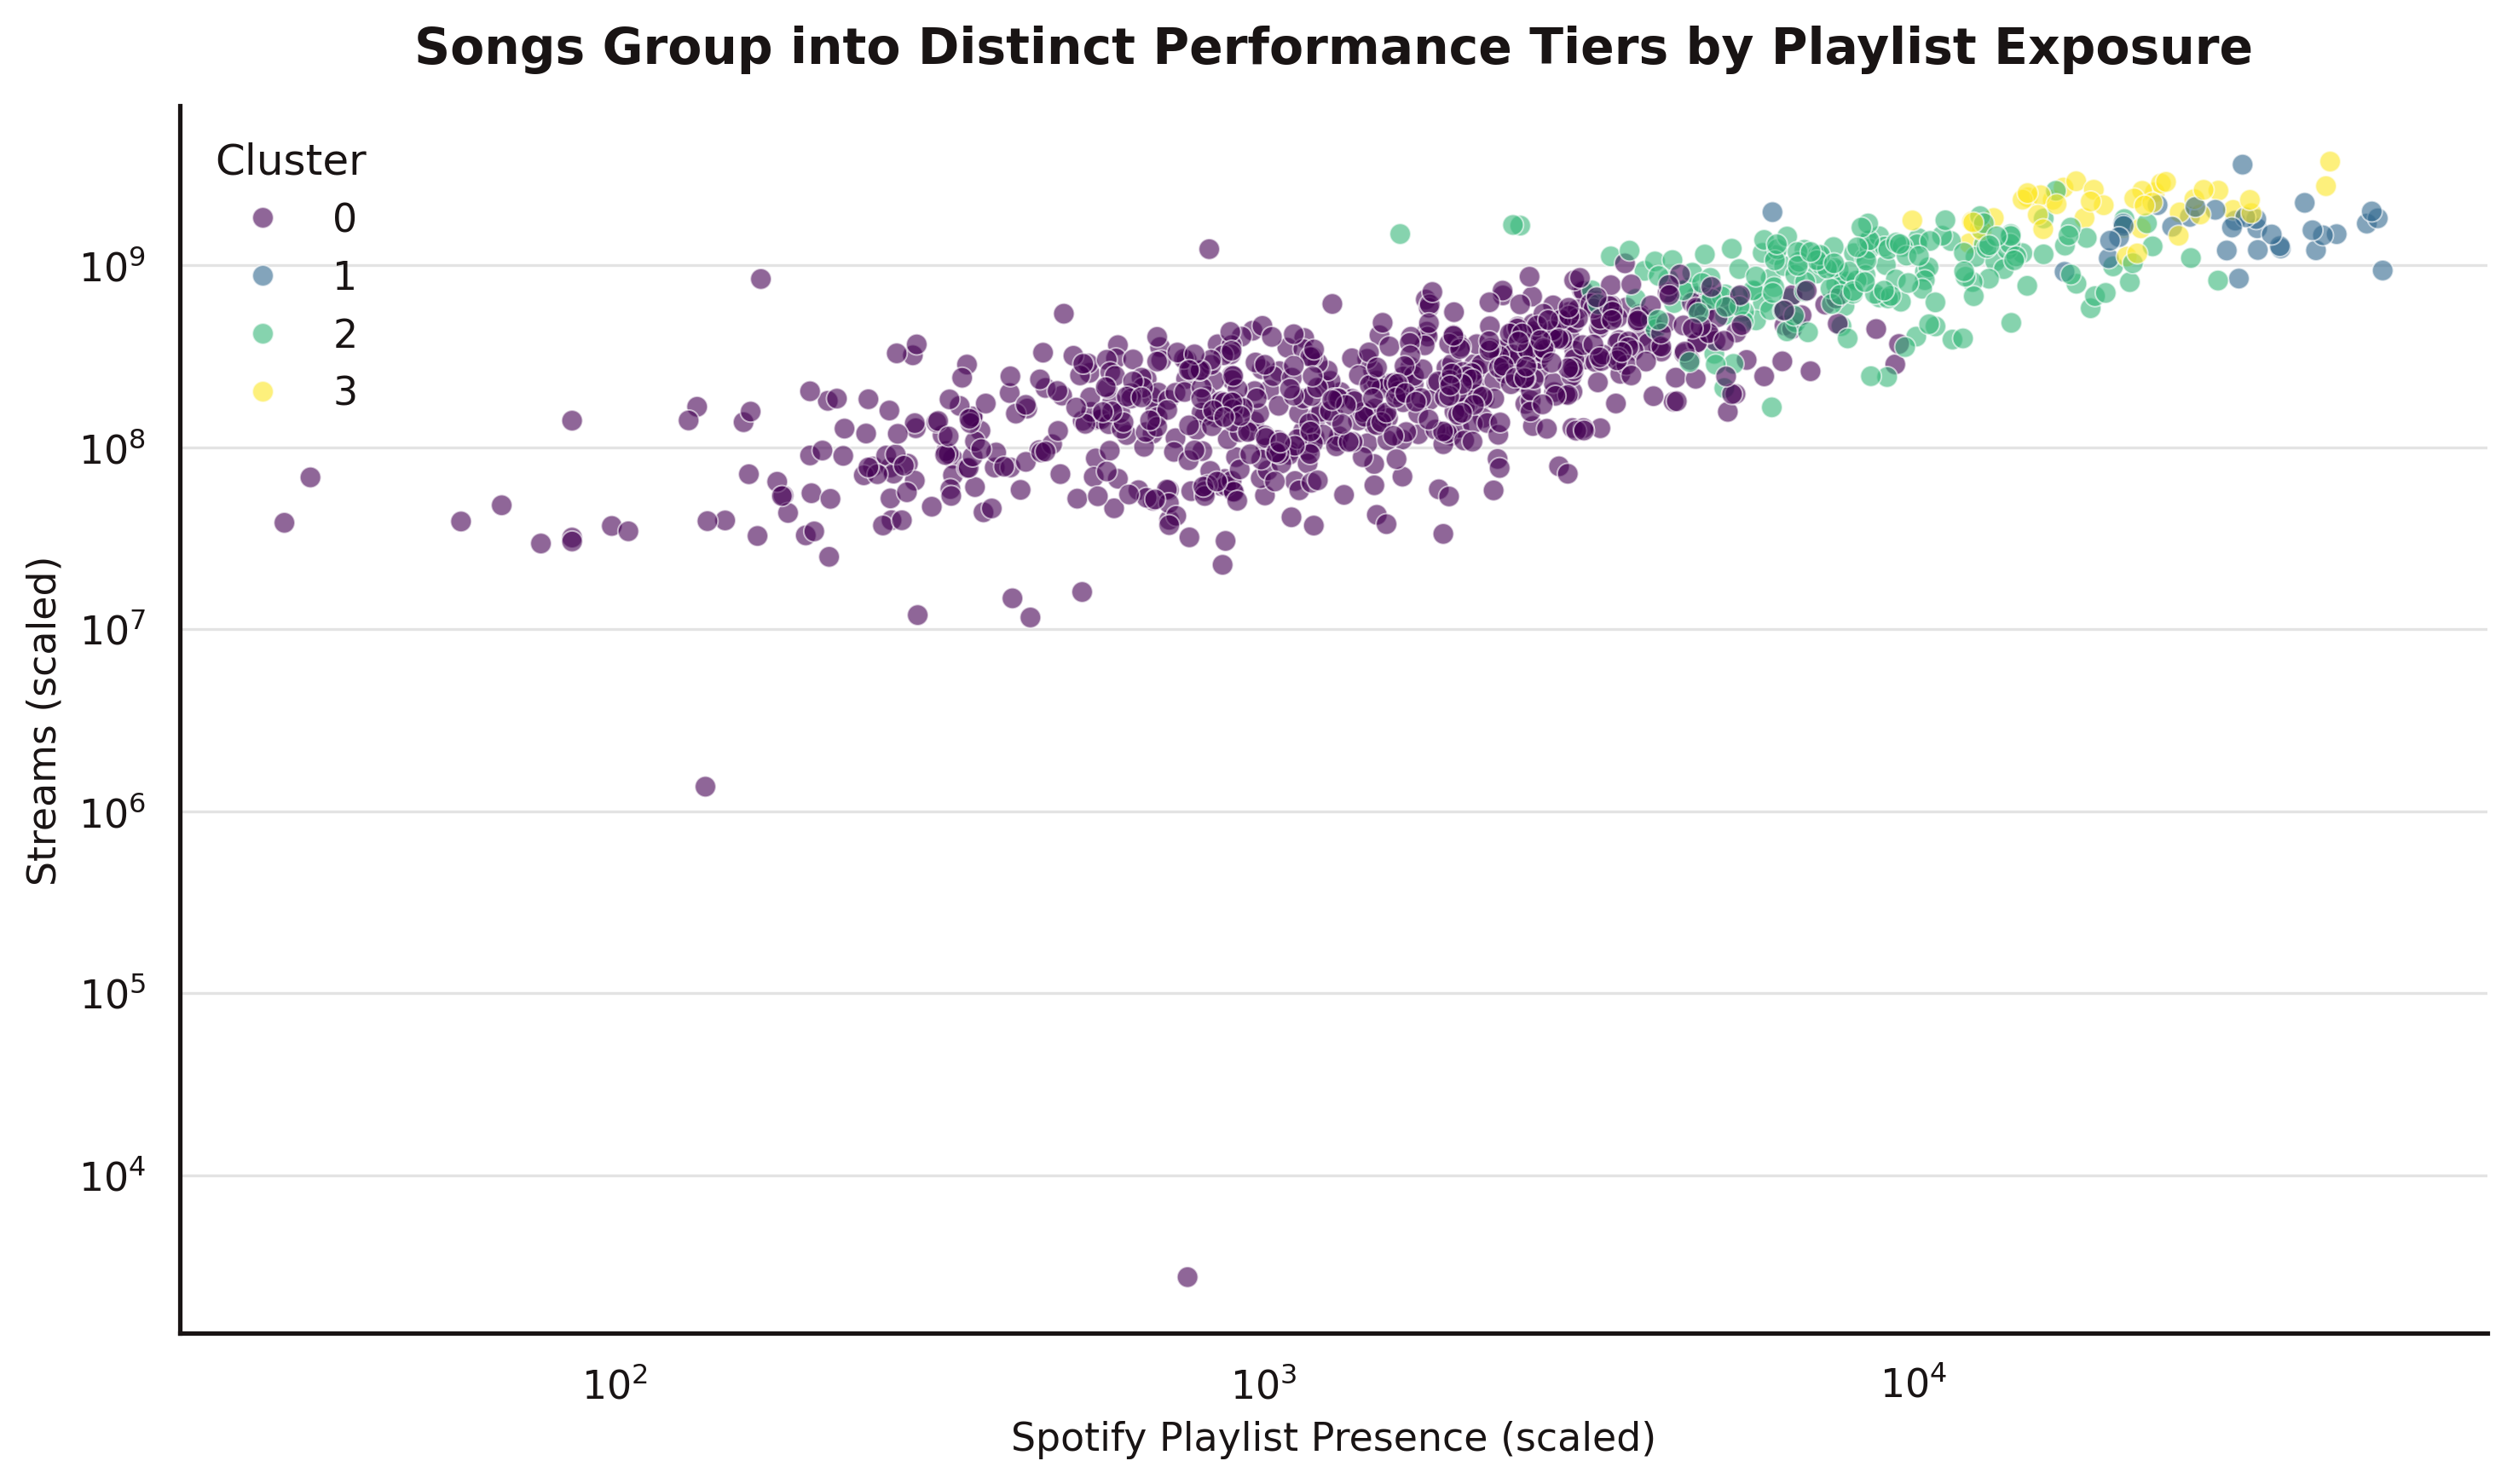

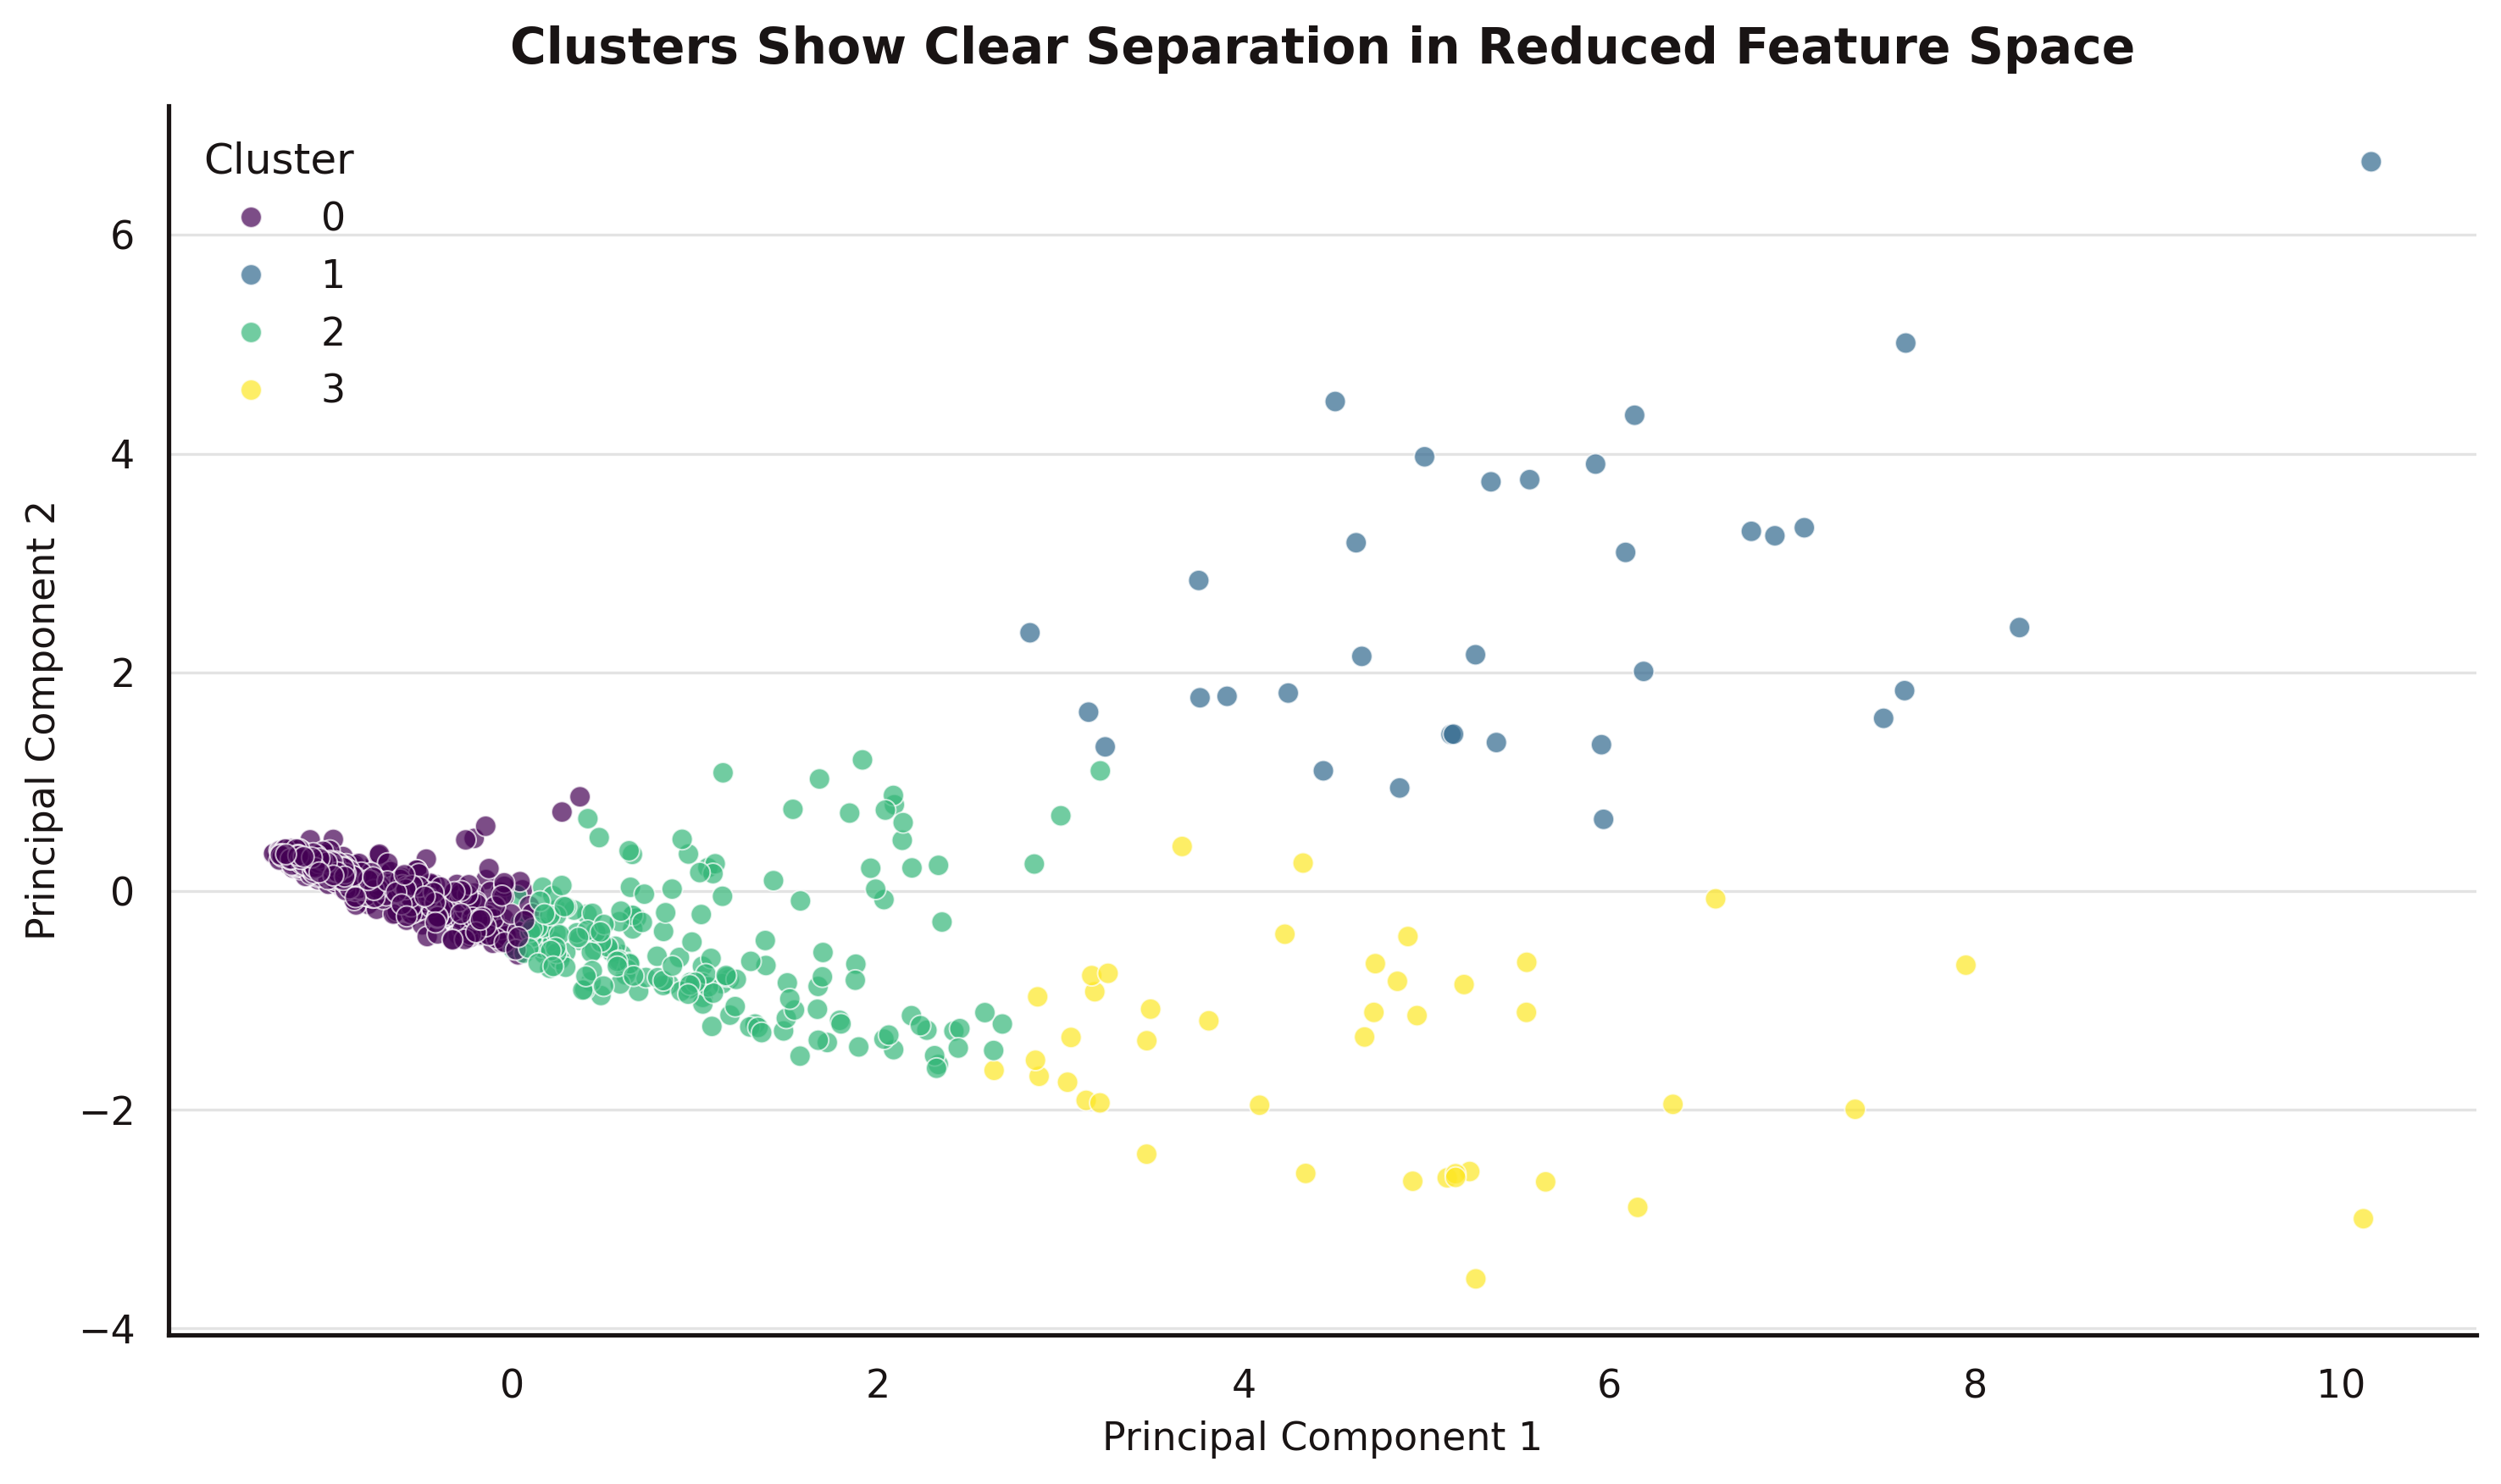

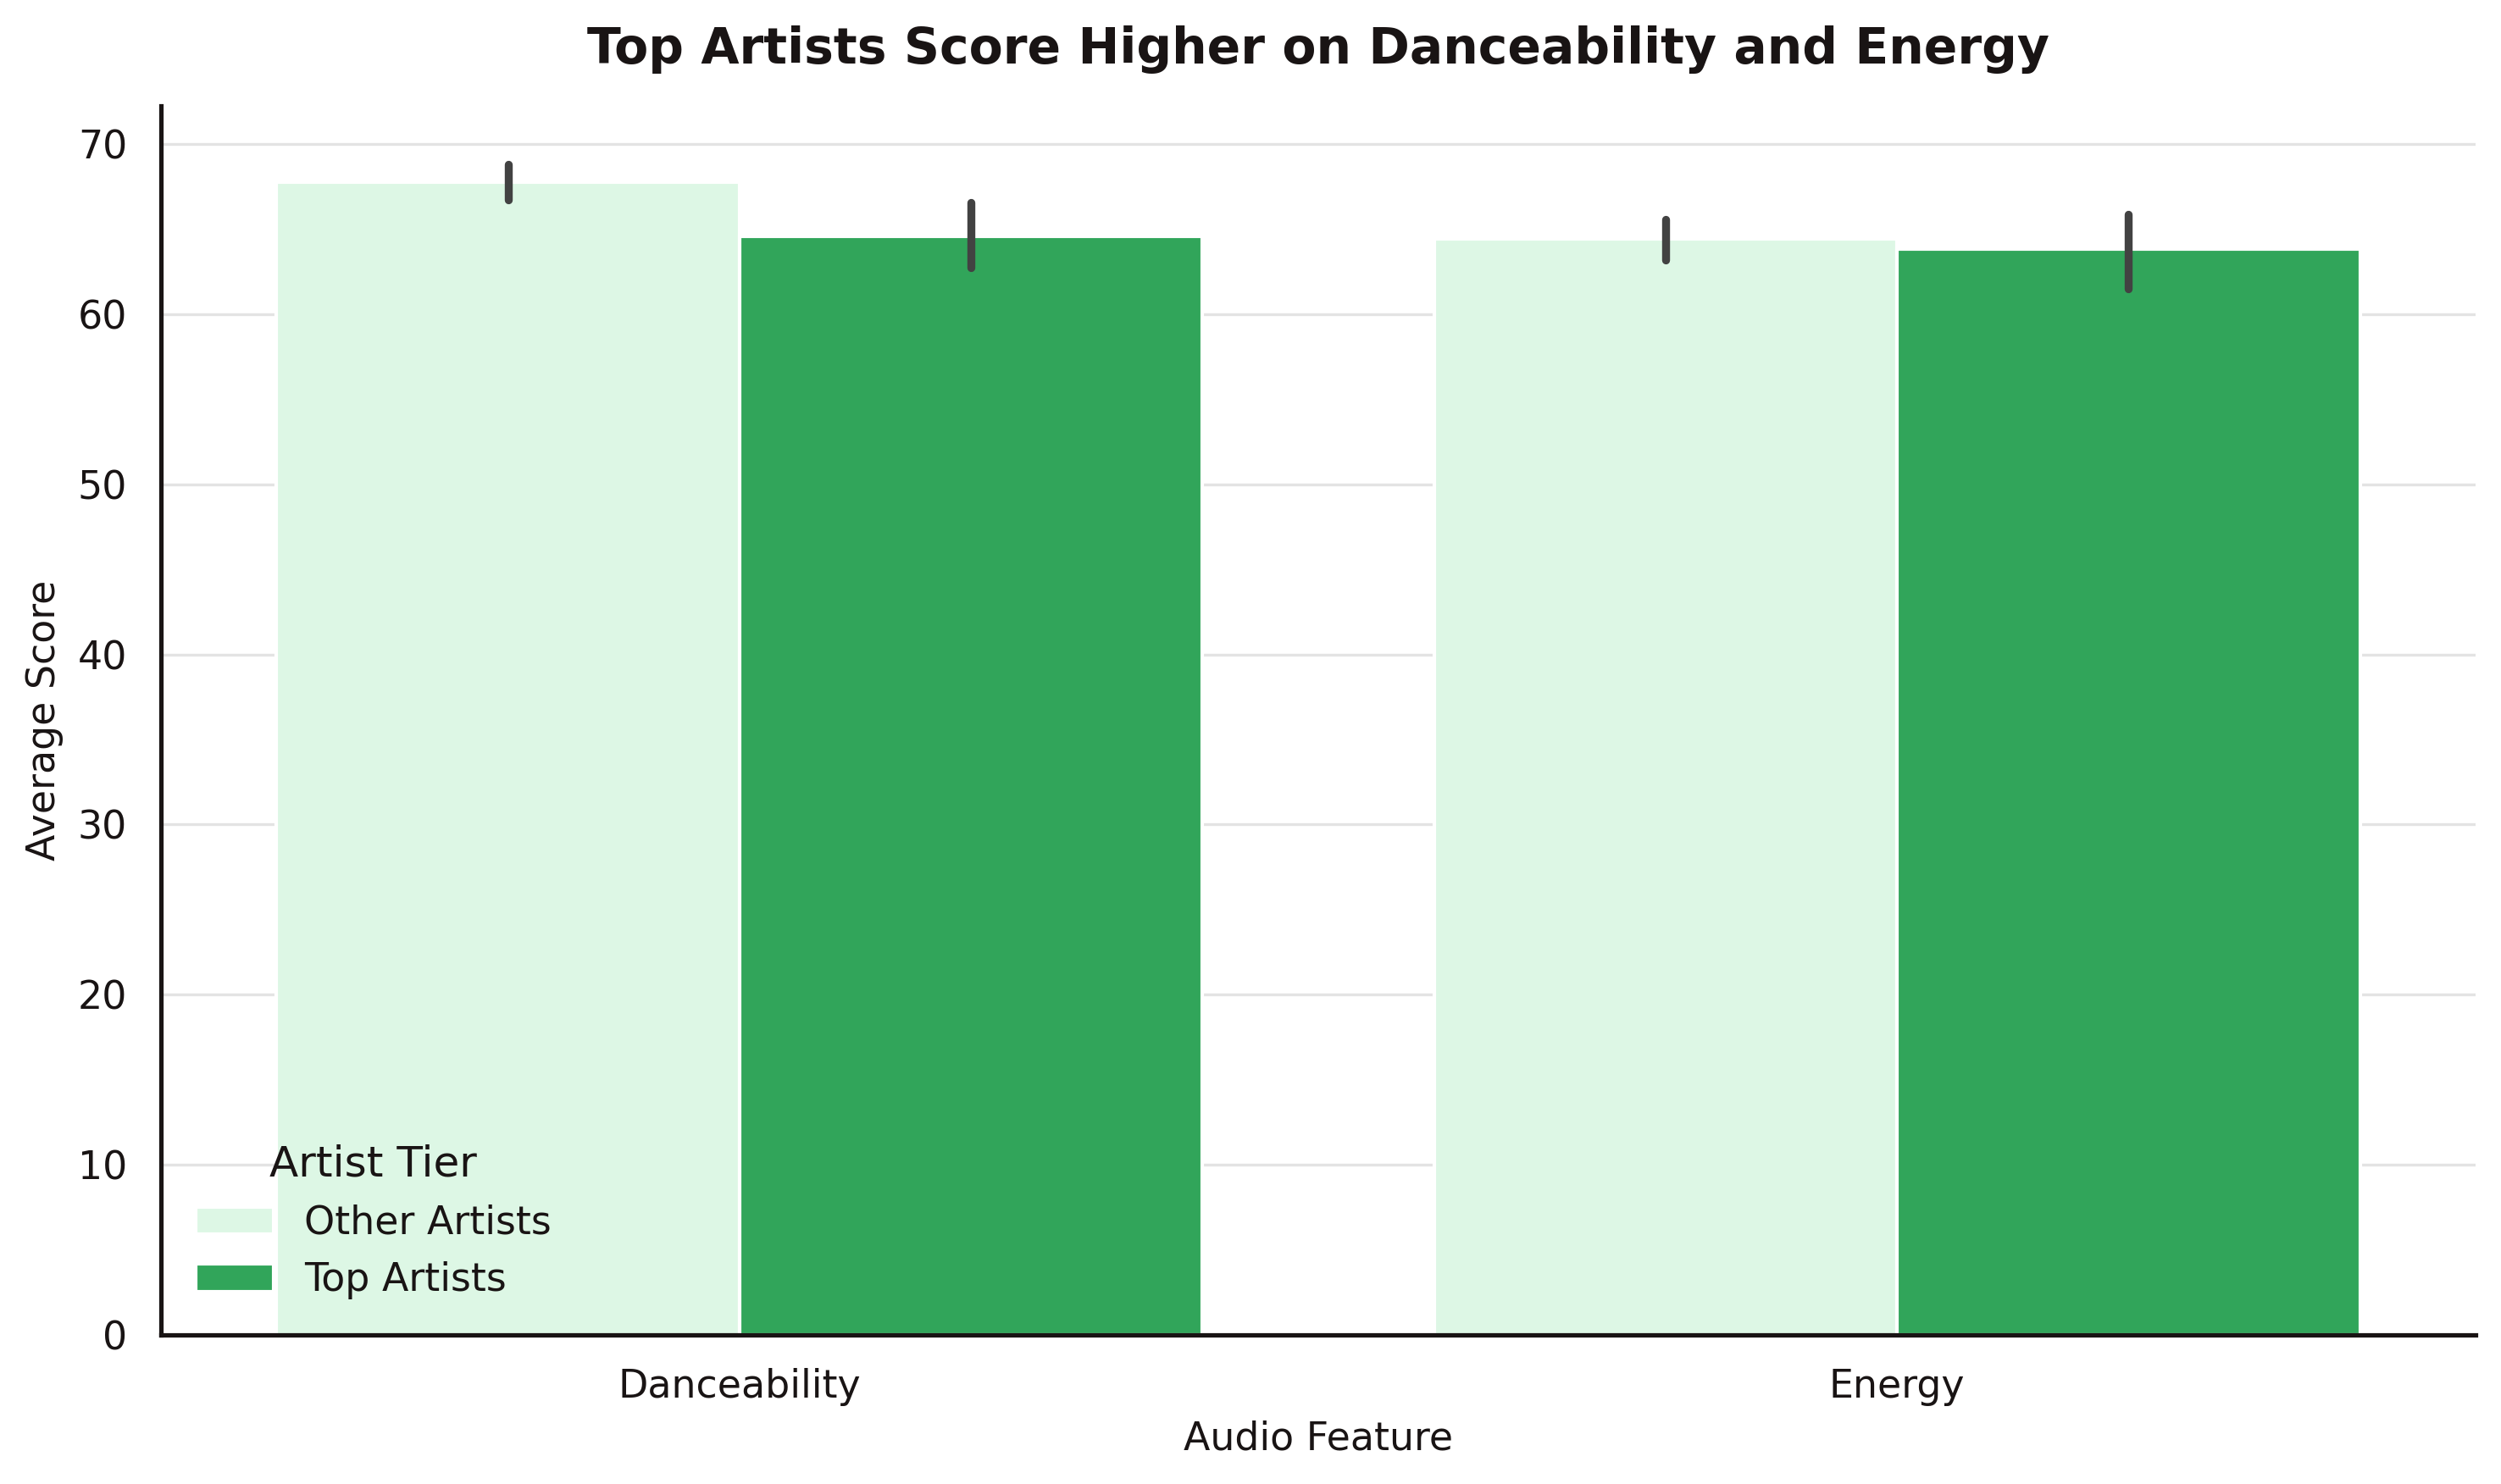

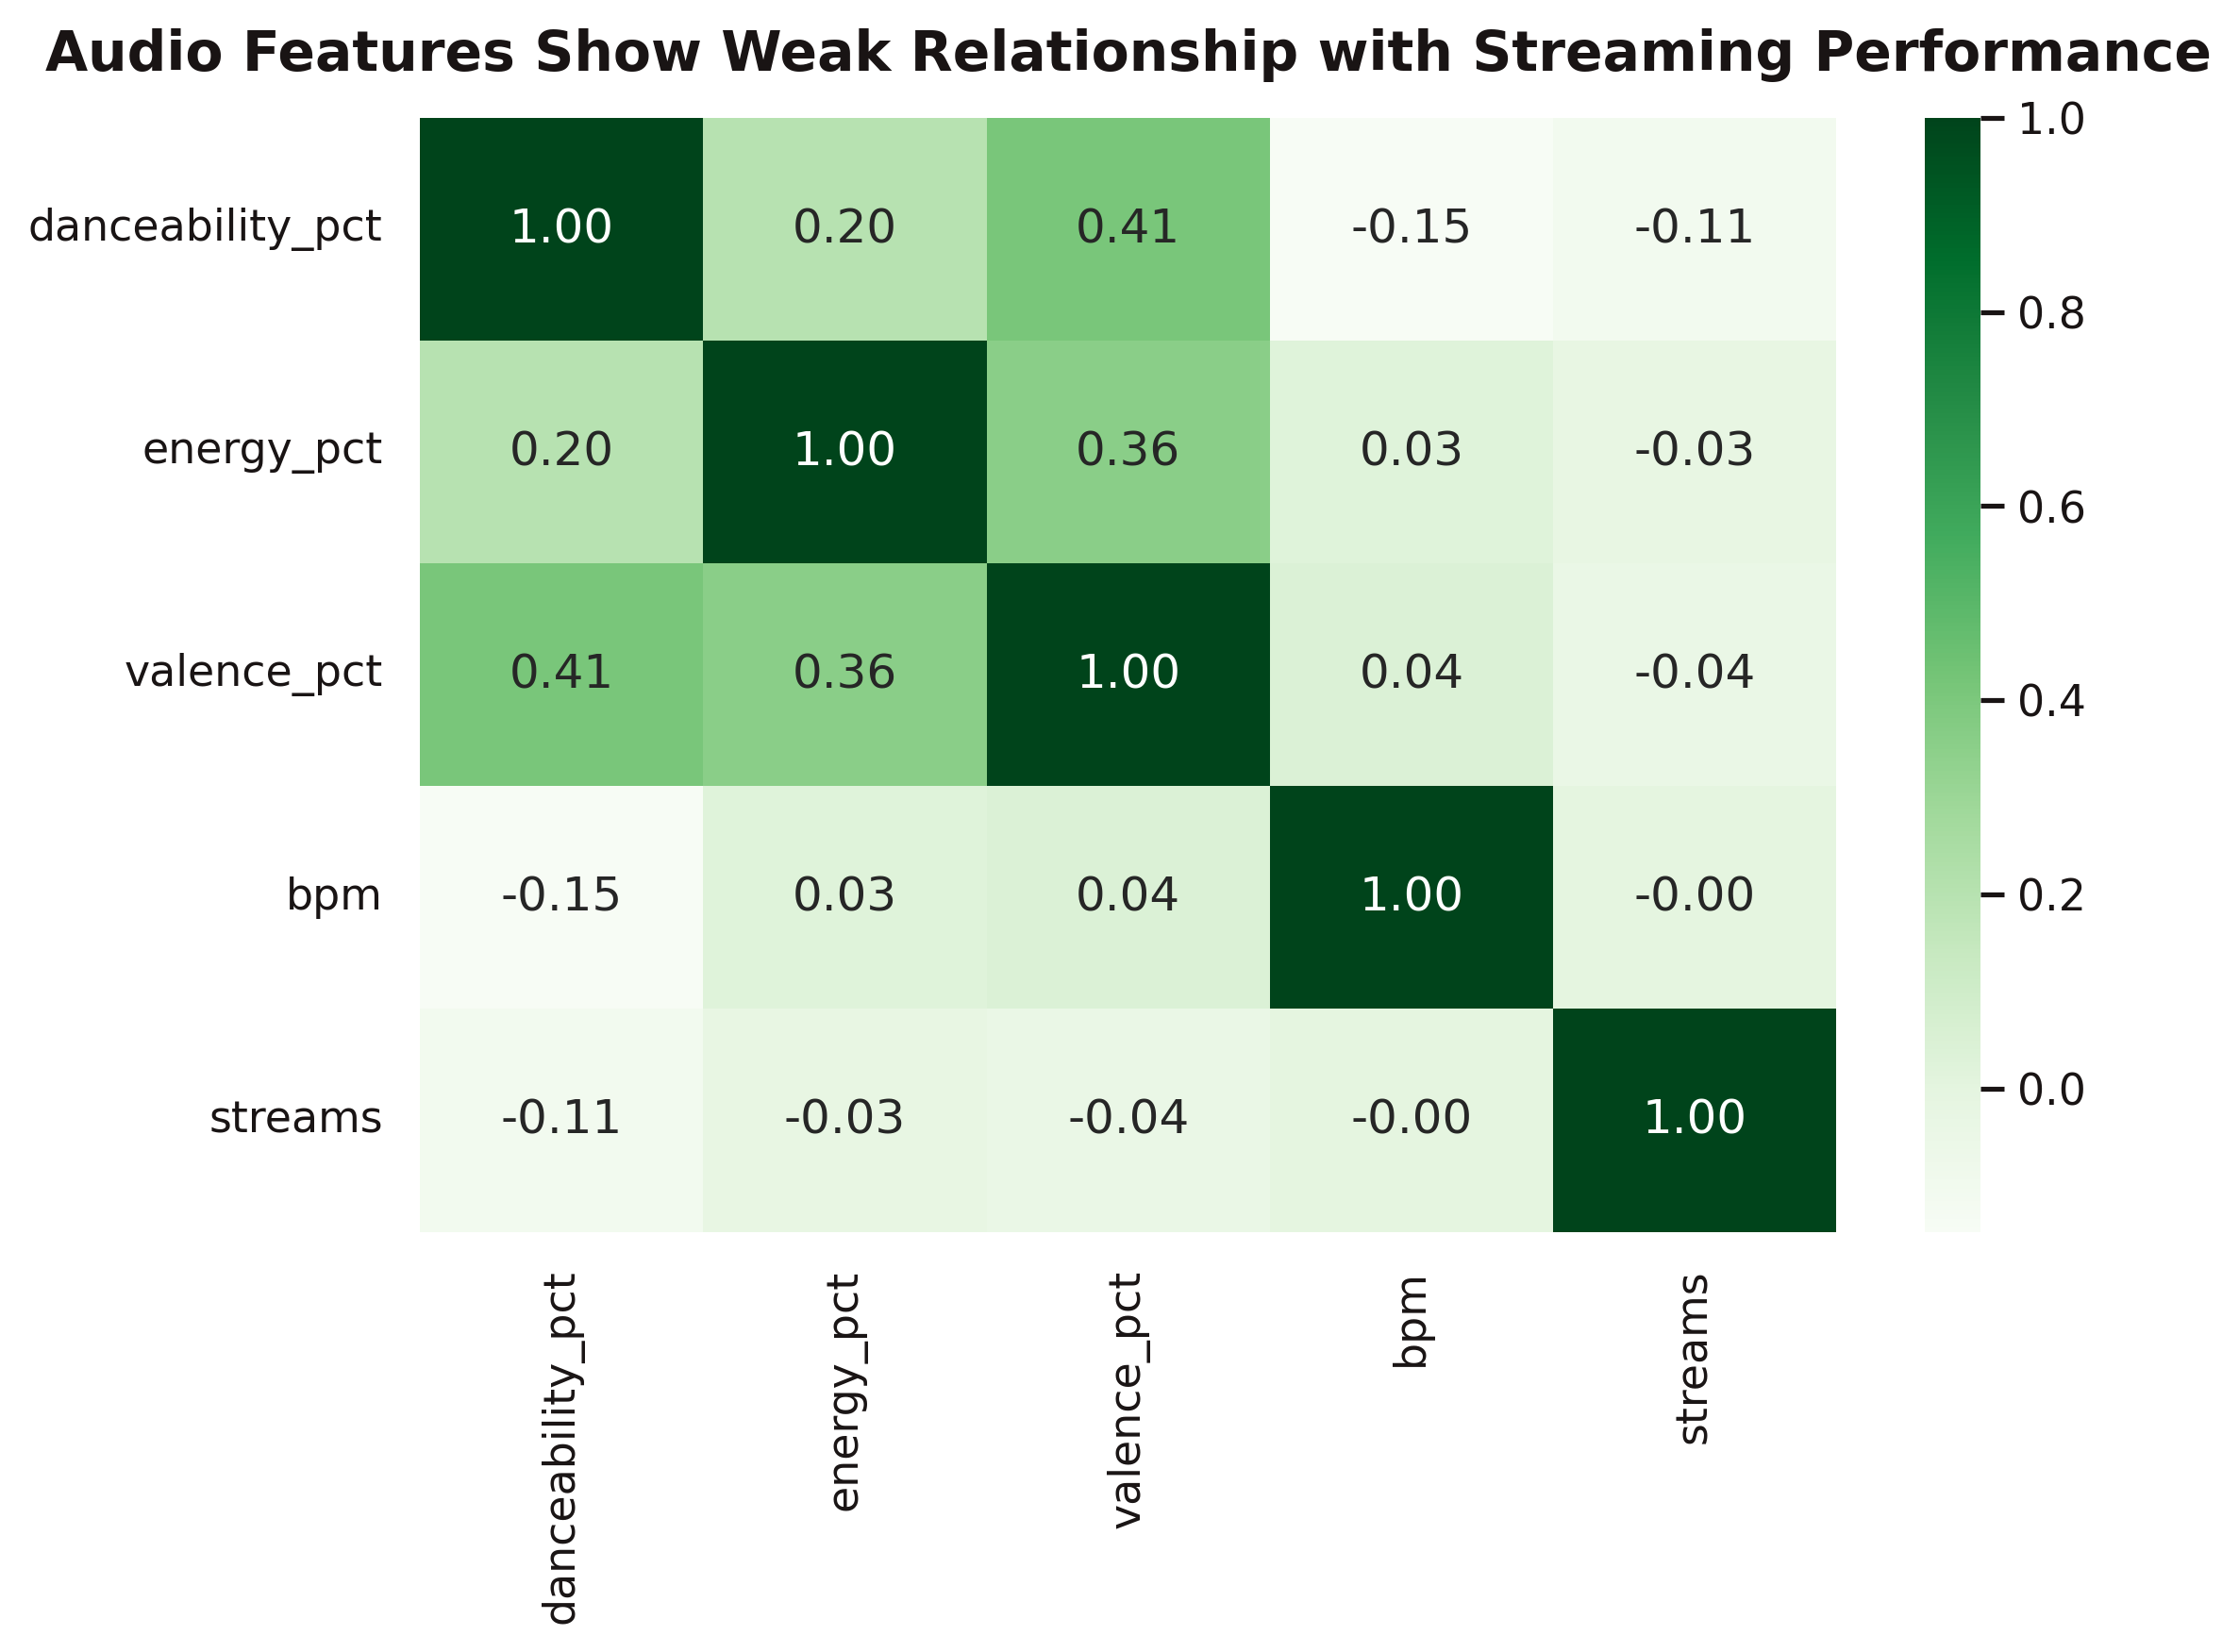


Created zip file: spotify_plots.zip


In [8]:
# ============================================================
# PREDICTING THE NEXT HIT SONG
# Spotify Streaming Analysis | Portfolio Version
# ============================================================

# ------------------------------------------------------------
# 1. Setup
# ------------------------------------------------------------
from google.colab import drive
drive.mount("/content/drive")

import os
import re
import warnings
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from google.colab import files
from IPython.display import Image, display
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import ttest_ind, chi2_contingency

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 2. File paths
# ------------------------------------------------------------
DATA_DIR = "/content/drive/MyDrive/spotify"
PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

for old_file in [
    "streams_distribution.png",
    "playlist_impact_comparison.png",
    "actual_vs_predicted_streams.png",
    "seasonal_performance_distribution.png",
    "playlist_clustering.png",
    "pca_clusters.png",
    "audio_feature_correlation.png",
    "artist_tier_audio_features.png"
]:
    old_path = os.path.join(PLOTS_DIR, old_file)
    if os.path.exists(old_path):
        os.remove(old_path)

# ------------------------------------------------------------
# 3. Visual style
# ------------------------------------------------------------
SPOTIFY_GREEN = "#1DB954"
SPOTIFY_DARK = "#191414"
SPOTIFY_GRID = "#dddddd"
SPOTIFY_BG = "#ffffff"

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.edgecolor"] = SPOTIFY_DARK
plt.rcParams["axes.labelcolor"] = SPOTIFY_DARK
plt.rcParams["xtick.color"] = SPOTIFY_DARK
plt.rcParams["ytick.color"] = SPOTIFY_DARK
plt.rcParams["text.color"] = SPOTIFY_DARK
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

def apply_chart_style(ax):
    ax.set_facecolor(SPOTIFY_BG)
    ax.grid(True, axis="y", color=SPOTIFY_GRID, linewidth=0.8, alpha=0.8)
    ax.grid(False, axis="x")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_color(SPOTIFY_DARK)
    ax.spines["bottom"].set_color(SPOTIFY_DARK)

def save_plot(filename: str) -> None:
    plt.tight_layout()
    plt.savefig(
        os.path.join(PLOTS_DIR, filename),
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )
    plt.close()

# ------------------------------------------------------------
# 4. Helper functions
# ------------------------------------------------------------
def detect_csv_file(data_dir: str) -> str:
    csv_files = [f for f in os.listdir(data_dir) if f.lower().endswith(".csv")]
    if not csv_files:
        raise FileNotFoundError(f"No CSV file found in {data_dir}")
    if len(csv_files) == 1:
        return os.path.join(data_dir, csv_files[0])

    preferred_patterns = ["spotify", "songs", "2023", "top"]
    for pattern in preferred_patterns:
        for file_name in csv_files:
            if pattern in file_name.lower():
                return os.path.join(data_dir, file_name)

    return os.path.join(data_dir, csv_files[0])

def clean_column_names(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [
        re.sub(r"[^a-z0-9_]+", "_", col.strip().lower()).strip("_")
        for col in df.columns
    ]
    return df

def clean_numeric_series(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace(",", "", regex=False),
        errors="coerce"
    )

def month_to_season(month: int) -> str:
    if month in [12, 1, 2]:
        return "Winter"
    if month in [3, 4, 5]:
        return "Spring"
    if month in [6, 7, 8]:
        return "Summer"
    return "Fall"

# ------------------------------------------------------------
# 5. Load Spotify file
# ------------------------------------------------------------
csv_path = detect_csv_file(DATA_DIR)
print("Using file:", csv_path)

spotify_raw = pd.read_csv(csv_path, encoding="latin1")
spotify_raw = clean_column_names(spotify_raw)

print("\nColumns found:")
print(spotify_raw.columns.tolist())

# ------------------------------------------------------------
# 6. Standardize key columns
# ------------------------------------------------------------
column_map_candidates = {
    "track_name": ["track_name"],
    "artist_name": ["artist_s_name", "artist_name", "artists_name"],
    "streams": ["streams"],
    "released_year": ["released_year"],
    "released_month": ["released_month"],
    "released_day": ["released_day"],
    "in_spotify_playlists": ["in_spotify_playlists"],
    "in_apple_playlists": ["in_apple_playlists"],
    "in_deezer_playlists": ["in_deezer_playlists"],
    "danceability_pct": ["danceability", "danceability_", "danceability_percent", "danceability_pct"],
    "energy_pct": ["energy", "energy_", "energy_percent", "energy_pct"],
    "valence_pct": ["valence", "valence_", "valence_percent", "valence_pct"],
    "bpm": ["bpm"]
}

resolved_cols = {}
for target, candidates in column_map_candidates.items():
    for candidate in candidates:
        if candidate in spotify_raw.columns:
            resolved_cols[target] = candidate
            break

for col in spotify_raw.columns:
    if "danceability" in col and "danceability_pct" not in resolved_cols:
        resolved_cols["danceability_pct"] = col
    if col.startswith("energy") and "in_" not in col and "energy_pct" not in resolved_cols:
        resolved_cols["energy_pct"] = col
    if "valence" in col and "valence_pct" not in resolved_cols:
        resolved_cols["valence_pct"] = col

required = [
    "track_name",
    "streams",
    "released_month",
    "in_spotify_playlists",
    "in_apple_playlists",
    "in_deezer_playlists"
]

missing_required = [col for col in required if col not in resolved_cols]
if missing_required:
    raise ValueError(f"Missing expected columns: {missing_required}")

# ------------------------------------------------------------
# 7. Prepare final dataset
# ------------------------------------------------------------
spotify = pd.DataFrame()
spotify["track_name"] = spotify_raw[resolved_cols["track_name"]]
spotify["streams"] = clean_numeric_series(spotify_raw[resolved_cols["streams"]])
spotify["released_month"] = clean_numeric_series(spotify_raw[resolved_cols["released_month"]])
spotify["in_spotify_playlists"] = clean_numeric_series(spotify_raw[resolved_cols["in_spotify_playlists"]])
spotify["in_apple_playlists"] = clean_numeric_series(spotify_raw[resolved_cols["in_apple_playlists"]])
spotify["in_deezer_playlists"] = clean_numeric_series(spotify_raw[resolved_cols["in_deezer_playlists"]])

if "artist_name" in resolved_cols:
    spotify["artist_name"] = spotify_raw[resolved_cols["artist_name"]].astype(str)

if "released_year" in resolved_cols:
    spotify["released_year"] = clean_numeric_series(spotify_raw[resolved_cols["released_year"]])

if "danceability_pct" in resolved_cols:
    spotify["danceability_pct"] = clean_numeric_series(spotify_raw[resolved_cols["danceability_pct"]])

if "energy_pct" in resolved_cols:
    spotify["energy_pct"] = clean_numeric_series(spotify_raw[resolved_cols["energy_pct"]])

if "valence_pct" in resolved_cols:
    spotify["valence_pct"] = clean_numeric_series(spotify_raw[resolved_cols["valence_pct"]])

if "bpm" in resolved_cols:
    spotify["bpm"] = clean_numeric_series(spotify_raw[resolved_cols["bpm"]])

spotify = spotify.dropna(subset=[
    "streams",
    "released_month",
    "in_spotify_playlists",
    "in_apple_playlists",
    "in_deezer_playlists"
]).copy()

spotify = spotify[spotify["streams"] > 0].reset_index(drop=True).copy()

spotify["season"] = spotify["released_month"].astype(int).apply(month_to_season)
spotify["total_playlist_presence"] = (
    spotify["in_spotify_playlists"] +
    spotify["in_apple_playlists"] +
    spotify["in_deezer_playlists"]
)
spotify["log_streams"] = np.log1p(spotify["streams"])

spotify["performance_tier"] = pd.qcut(
    spotify["streams"],
    q=4,
    labels=["Lower", "Mid-Lower", "Mid-Upper", "Top"]
)

# Define top artists: artists whose total streams place them in the top 25%
if "artist_name" in spotify.columns:
    artist_streams = spotify.groupby("artist_name")["streams"].sum()
    top_artist_threshold = artist_streams.quantile(0.75)
    top_artists = artist_streams[artist_streams >= top_artist_threshold].index
    spotify["is_top_artist"] = spotify["artist_name"].isin(top_artists)
else:
    # Fallback: define top artists by song-level stream percentile
    spotify["is_top_artist"] = spotify["streams"] >= spotify["streams"].quantile(0.75)

print("\nPrepared dataset shape:", spotify.shape)
print(f"Top artists defined: {spotify['is_top_artist'].sum()} songs from top-tier artists")
print("\nDescriptive statistics:")
print(
    spotify[
        ["streams", "in_spotify_playlists", "in_apple_playlists", "in_deezer_playlists"]
    ].describe()
)

# ------------------------------------------------------------
# 8. Regression model
# ------------------------------------------------------------
model_df = spotify[[
    "log_streams",
    "in_spotify_playlists",
    "in_apple_playlists",
    "in_deezer_playlists"
]].dropna().copy()

X = sm.add_constant(model_df[[
    "in_spotify_playlists",
    "in_apple_playlists",
    "in_deezer_playlists"
]])
y = model_df["log_streams"]

model = sm.OLS(y, X).fit()

print("\n" + "=" * 70)
print("REGRESSION SUMMARY")
print("=" * 70)
print(model.summary())

# Standardized coefficients for platform comparison
scaled_df = model_df.copy()
for col in ["in_spotify_playlists", "in_apple_playlists", "in_deezer_playlists", "log_streams"]:
    scaled_df[col] = (scaled_df[col] - scaled_df[col].mean()) / scaled_df[col].std()

X_scaled = sm.add_constant(scaled_df[[
    "in_spotify_playlists",
    "in_apple_playlists",
    "in_deezer_playlists"
]])
y_scaled = scaled_df["log_streams"]
scaled_model = sm.OLS(y_scaled, X_scaled).fit()

coef_summary = pd.DataFrame({
    "platform": ["Spotify", "Apple Music", "Deezer"],
    "coefficient": [
        scaled_model.params["in_spotify_playlists"],
        scaled_model.params["in_apple_playlists"],
        scaled_model.params["in_deezer_playlists"]
    ]
}).sort_values("coefficient", ascending=False)

spotify["predicted_log_streams"] = np.nan
spotify.loc[model_df.index, "predicted_log_streams"] = model.predict(X)
spotify["predicted_streams"] = np.expm1(spotify["predicted_log_streams"])

print("\n" + "=" * 70)
print("KEY FINDINGS SUMMARY")
print("=" * 70)
print(f"\nDataset size: {len(spotify):,}")
print(f"R-squared: {model.rsquared:.4f}")
print(f"Adj. R-squared: {model.rsquared_adj:.4f}")
print("\nRelative playlist impact (standardized coefficients):")
print(coef_summary.to_string(index=False))

# ------------------------------------------------------------
# 9. Hypothesis testing
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("HYPOTHESIS TESTING")
print("=" * 70)

# T-test: do top artists score higher on danceability and energy?
feature_cols = ["danceability_pct", "energy_pct"]
available_features = [col for col in feature_cols if col in spotify.columns]

if available_features:
    top_songs = spotify[spotify["is_top_artist"] == True]
    non_top_songs = spotify[spotify["is_top_artist"] == False]

    for feature in available_features:
        top_vals = top_songs[feature].dropna()
        non_top_vals = non_top_songs[feature].dropna()
        t_stat, p_val = ttest_ind(top_vals, non_top_vals, equal_var=False)
        print(f"\nT-test: Top Artists vs Non-Top Artists on {feature}")
        print(f"  Top artist mean:     {top_vals.mean():.2f}")
        print(f"  Non-top artist mean: {non_top_vals.mean():.2f}")
        print(f"  T-statistic: {t_stat:.4f}")
        print(f"  P-value: {p_val:.6f}")
        print(f"  Significant: {'Yes' if p_val < 0.05 else 'No'}")
else:
    print("Audio feature columns not found — skipping t-tests")

# Chi-square: season vs performance tier
contingency = pd.crosstab(spotify["season"], spotify["performance_tier"])
chi2_stat, chi2_p_value, chi2_dof, chi2_expected = chi2_contingency(contingency)

print(f"\nChi-square Test: Release Season vs Performance Tier")
print(f"  Chi-square: {chi2_stat:.4f}")
print(f"  Degrees of freedom: {chi2_dof}")
print(f"  P-value: {chi2_p_value:.6f}")
print(f"  Significant: {'Yes' if chi2_p_value < 0.05 else 'No'}")

# ------------------------------------------------------------
# 10. Clustering and PCA
# ------------------------------------------------------------
cluster_df = spotify[[
    "streams",
    "in_spotify_playlists",
    "in_apple_playlists",
    "in_deezer_playlists"
]].dropna().copy()

scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_df)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_df["cluster"] = kmeans.fit_predict(scaled_features)

spotify["cluster"] = np.nan
spotify.loc[cluster_df.index, "cluster"] = cluster_df["cluster"]

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)
cluster_df["pca1"] = pca_result[:, 0]
cluster_df["pca2"] = pca_result[:, 1]

print("\n" + "=" * 70)
print("CLUSTERING RESULTS")
print("=" * 70)
print(cluster_df["cluster"].value_counts().sort_index())
print(f"\nPCA explained variance: {pca.explained_variance_ratio_.sum():.2%}")

# ------------------------------------------------------------
# 11. Audio feature correlation
# ------------------------------------------------------------
all_feature_cols = ["danceability_pct", "energy_pct", "valence_pct", "bpm"]
available_all = [col for col in all_feature_cols if col in spotify.columns]

if available_all:
    corr_df = spotify[available_all + ["streams"]].dropna().copy()
    feature_corr = corr_df.corr()
    print("\n" + "=" * 70)
    print("AUDIO FEATURE CORRELATIONS WITH STREAMS")
    print("=" * 70)
    print(feature_corr["streams"].drop("streams"))
else:
    feature_corr = None

# ------------------------------------------------------------
# 12. Portfolio-ready charts
# ------------------------------------------------------------

# 12A. Streams distribution
fig, ax = plt.subplots()
sns.histplot(
    spotify["log_streams"],
    bins=40,
    color=SPOTIFY_GREEN,
    edgecolor="white",
    linewidth=0.3,
    ax=ax
)
ax.set_title("Most Songs Receive Moderate Streaming Attention", pad=12)
ax.set_xlabel("Streaming Performance (scaled for readability)")
ax.set_ylabel("Number of Songs")
apply_chart_style(ax)
save_plot("streams_distribution.png")

# 12B. Playlist platform impact
fig, ax = plt.subplots()
sns.barplot(
    data=coef_summary,
    x="platform",
    y="coefficient",
    color=SPOTIFY_GREEN,
    ax=ax
)
ax.set_title("Spotify Playlists Have the Strongest Impact on Streams", pad=12)
ax.set_xlabel("Platform")
ax.set_ylabel("Relative Influence on Streaming Performance")
apply_chart_style(ax)
save_plot("playlist_impact_comparison.png")

# 12C. Actual vs predicted
fit_base = spotify.dropna(subset=["predicted_streams"])
fit_sample = fit_base.sample(min(300, len(fit_base)), random_state=42).copy()

fig, ax = plt.subplots()
sns.scatterplot(
    data=fit_sample,
    x="streams",
    y="predicted_streams",
    alpha=0.35,
    s=30,
    color=SPOTIFY_GREEN,
    edgecolor=None,
    ax=ax
)

max_val = max(
    fit_sample["streams"].quantile(0.98),
    fit_sample["predicted_streams"].quantile(0.98)
)

ax.plot(
    [1, max_val],
    [1, max_val],
    linestyle="--",
    color=SPOTIFY_DARK,
    linewidth=1.5
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Model Captures Overall Streaming Trends", pad=12)
ax.set_xlabel("Actual Streams (scaled)")
ax.set_ylabel("Predicted Streams (scaled)")
apply_chart_style(ax)
save_plot("actual_vs_predicted_streams.png")

# 12D. Seasonal performance distribution
season_perf = (
    spotify.groupby(["season", "performance_tier"], observed=False)
    .size()
    .reset_index(name="count")
)

season_order = ["Spring", "Summer", "Fall", "Winter"]
tier_order = ["Lower", "Mid-Lower", "Mid-Upper", "Top"]

season_perf["season"] = pd.Categorical(
    season_perf["season"],
    categories=season_order,
    ordered=True
)
season_perf["performance_tier"] = pd.Categorical(
    season_perf["performance_tier"],
    categories=tier_order,
    ordered=True
)

season_perf = season_perf.sort_values(["season", "performance_tier"])

season_pivot = season_perf.pivot(
    index="season",
    columns="performance_tier",
    values="count"
).fillna(0)

season_pct = season_pivot.div(season_pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots()
bottom = np.zeros(len(season_pct))
stack_colors = ["#d9fbe3", "#8be0a6", "#41c96b", SPOTIFY_GREEN]

for i, col in enumerate(season_pct.columns):
    ax.bar(
        season_pct.index,
        season_pct[col],
        bottom=bottom,
        label=col,
        color=stack_colors[i]
    )
    bottom += season_pct[col].values

ax.set_title("Song Performance Mix Changes Across Release Seasons", pad=12)
ax.set_xlabel("Release Season")
ax.set_ylabel("Share of Songs")
ax.legend(title="Performance Tier", frameon=False)
apply_chart_style(ax)
save_plot("seasonal_performance_distribution.png")

# 12E. Clustering: playlist presence vs streams
fig, ax = plt.subplots()
sns.scatterplot(
    data=cluster_df,
    x="in_spotify_playlists",
    y="streams",
    hue="cluster",
    palette="viridis",
    alpha=0.6,
    s=35,
    ax=ax
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Songs Group into Distinct Performance Tiers by Playlist Exposure", pad=12)
ax.set_xlabel("Spotify Playlist Presence (scaled)")
ax.set_ylabel("Streams (scaled)")
ax.legend(title="Cluster", frameon=False)
apply_chart_style(ax)
save_plot("playlist_clustering.png")

# 12F. PCA cluster visualization
fig, ax = plt.subplots()
sns.scatterplot(
    data=cluster_df,
    x="pca1",
    y="pca2",
    hue="cluster",
    palette="viridis",
    alpha=0.7,
    s=35,
    ax=ax
)
ax.set_title("Clusters Show Clear Separation in Reduced Feature Space", pad=12)
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.legend(title="Cluster", frameon=False)
apply_chart_style(ax)
save_plot("pca_clusters.png")

# 12G. Top vs non-top artist audio features
if available_features:
    feature_compare = spotify[available_features + ["is_top_artist"]].dropna().copy()
    feature_compare["artist_tier"] = feature_compare["is_top_artist"].map(
        {True: "Top Artists", False: "Other Artists"}
    )
    feature_melt = feature_compare.melt(
        id_vars="artist_tier",
        value_vars=available_features,
        var_name="feature",
        value_name="score"
    )
    feature_melt["feature"] = feature_melt["feature"].str.replace("_pct", "").str.title()

    fig, ax = plt.subplots()
    sns.barplot(
        data=feature_melt,
        x="feature",
        y="score",
        hue="artist_tier",
        palette={
            "Top Artists": SPOTIFY_GREEN,
            "Other Artists": "#d9fbe3"
        },
        ax=ax
    )
    ax.set_title("Top Artists Score Higher on Danceability and Energy", pad=12)
    ax.set_xlabel("Audio Feature")
    ax.set_ylabel("Average Score")
    ax.legend(title="Artist Tier", frameon=False)
    apply_chart_style(ax)
    save_plot("artist_tier_audio_features.png")

# 12H. Audio feature correlation heatmap
if feature_corr is not None:
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        feature_corr,
        annot=True,
        cmap="Greens",
        fmt=".2f",
        ax=ax
    )
    ax.set_title("Audio Features Show Weak Relationship with Streaming Performance", pad=12)
    save_plot("audio_feature_correlation.png")

print("\nSaved plots:")
print(sorted(os.listdir(PLOTS_DIR)))

# ------------------------------------------------------------
# 13. Preview all charts
# ------------------------------------------------------------
for file_name in [
    "streams_distribution.png",
    "playlist_impact_comparison.png",
    "actual_vs_predicted_streams.png",
    "seasonal_performance_distribution.png",
    "playlist_clustering.png",
    "pca_clusters.png",
    "artist_tier_audio_features.png",
    "audio_feature_correlation.png"
]:
    full_path = os.path.join(PLOTS_DIR, file_name)
    if os.path.exists(full_path):
        display(Image(filename=full_path))

# ------------------------------------------------------------
# 14. Optional: zip plots for download
# ------------------------------------------------------------
shutil.make_archive("spotify_plots", "zip", PLOTS_DIR)
print("\nCreated zip file: spotify_plots.zip")
# files.download("spotify_plots.zip")